# Spruce-budworm: NODE gradient learning → symbolic distillation → extrapolation tests

**Goal.** Generate data from a *known* analytic ODE, fit a Neural ODE (NODE) to the noisy
trajectories, use the trained NODE as a smooth **gradient estimator**, distill that gradient
field into closed-form equations with **SINDy**, **SINDy-PI**, and **SyMANTIC**, and finally
compare how all four models behave *inside* and *outside* the training regime.

**True model** (spruce-budworm outbreak, [mathinsight](https://mathinsight.org/spruce_budworm_outbreak_model)):
$$\frac{dw}{dt} = r\,w\left(1-\frac{w}{a}\right) - \frac{w^2}{1+w^2},\qquad r=0.5,\ a=10.$$
This field has two **stable** equilibria — a low "refuge" state ($w\approx0.7$) and a high
"outbreak" state ($w\approx7.3$) — separated by an **unstable** point near $w\approx2$.
The $w^2/(1+w^2)$ term is **rational**, which is the crux of the symbolic-regression story later.

**Two distinct extrapolation tests appear throughout — they live on different axes:**
- **State extrapolation** — query the field at $w>W_{\max}=8$ (up to 16): states never seen in training.
- **Time extrapolation** — integrate trajectories past $t=T_\text{final}=5$ (up to 12): beyond the training time horizon.

---

### This cell — Stage 1 & 2: data generation + NODE training + gradient validation
- **Config.** State window $w\in[0.05,8]$, 80 initial conditions, 25 time points on $t\in[0,5]$, observation noise `NOISE_STD=0.05`.
- **Data.** `make_data()` integrates the true ODE to high accuracy, adds Gaussian noise, pins $t=0$ to the exact IC, and clamps $w\ge0$ (biomass can't be negative).
- **NODE.** `VectorField` is an autonomous MLP $f_\theta(w)$ (input scaled by $W_{\max}$); `train_node` fits it by integrating with fixed-step RK4 and matching the noisy trajectories (MSE).
- **Gradient extraction.** `node_field` evaluates $f_\theta(w)$ directly — this **is** the NODE's estimate of $dw/dt$, the quantity every symbolic method is distilled from.
- **Stage 2 result (this run).** NODE field vs analytic derivative: **R²≈0.995, RMSE≈0.009, MAE≈0.005** — the learned field matches the truth well inside the window.

In [1]:
"""
================================================================================
Spruce budworm: Neural ODE gradient learning and extrapolation tests
================================================================================

True model:

    dw/dt = r*w*(1 - w/a) - w^2/(1+w^2) (https://mathinsight.org/spruce_budworm_outbreak_model)
"""

import numpy as np
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp
from torchdiffeq import odeint

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


# ============================================================================
# Reproducibility and plotting style
# ============================================================================

torch.manual_seed(0)
np.random.seed(0)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
    "axes.titleweight": "bold",
})

C = {
    "true": "#111111",
    "node": "#2ca02c",
    "data": "#999999",
    "ex": "#f0eef6",
}


# ============================================================================
# Configuration
# ============================================================================

R, A = 0.5, 10.0

W_MIN, W_MAX = 0.05, 8.0       # training state window
W_EXTRAP = 16.0                # state extrapolation limit

N_IC = 80                      # number of initial conditions
T_FINAL = 5.0                  # training time horizon
N_T = 25                       # number of observed time points

NOISE_STD = 0.05               # observation noise
N_EPOCHS = 1500

T_LONG = 12.0                  # time extrapolation horizon


# True model
def true_f(w, r=R, a=A):
    return r * w * (1 - w / a) - w**2 / (1 + w**2)


# Data generation
def make_data():
    t = np.linspace(0, T_FINAL, N_T)
    ics = np.linspace(W_MIN, W_MAX, N_IC)

    clean = np.stack([
        solve_ivp(
            lambda tt, w: true_f(w),
            (0, T_FINAL),
            [w0],
            t_eval=t,
            rtol=1e-10,
            atol=1e-10,
        ).y[0]
        for w0 in ics
    ])

    noisy = clean + NOISE_STD * np.random.randn(*clean.shape)
    noisy[:, 0] = ics

    noisy = np.maximum(noisy, 1e-8) #cannot be negatie so we are clamping it to be positive

    return t, ics, noisy, clean.copy()

class VectorField(nn.Module):

    def __init__(self, scale=W_MAX, hidden=96):
        super().__init__()

        self.scale = scale

        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, t, w):
        return self.net(w / self.scale)


def train_node(t, ics, traj):

    t_t = torch.tensor(t, dtype=torch.float32)
    w0 = torch.tensor(ics.reshape(-1, 1), dtype=torch.float32)

    obs = torch.tensor(traj.T[..., None], dtype=torch.float32)

    vf = VectorField()
    vf.train()

    opt = torch.optim.Adam(vf.parameters(), lr=3e-3)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, N_EPOCHS)

    for ep in range(N_EPOCHS):
        opt.zero_grad()
        pred = odeint(vf, w0, t_t, method="rk4")

        loss = ((pred - obs) ** 2).mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(vf.parameters(), 1.0)

        opt.step()
        sch.step()

        if ep % 400 == 0 or ep == N_EPOCHS - 1:
            print(f"  epoch {ep:4d}  traj-MSE {loss.item():.2e}")

    return vf


def node_field(vf, w):

    vf.eval()
    w = np.asarray(w)

    with torch.no_grad():
        wt = torch.tensor(w.reshape(-1, 1), dtype=torch.float32)
        return vf(0.0, wt).cpu().numpy().ravel()


def integrate_true(w0, t_eval):

    sol = solve_ivp(
        lambda tt, w: true_f(w),
        (t_eval[0], t_eval[-1]),
        [w0],
        t_eval=t_eval,
        rtol=1e-9,
        atol=1e-11,
        max_step=0.05,
    )

    if sol.y.shape[1] == len(t_eval):
        return sol.y[0]

    out = np.full_like(t_eval, np.nan)
    out[0] = w0
    return out


def integrate_node(vf, w0, t_eval):

    vf.eval()

    t_t = torch.tensor(t_eval, dtype=torch.float32)
    w0_t = torch.tensor([[w0]], dtype=torch.float32)

    with torch.no_grad():
        pred = odeint(vf, w0_t, t_t, method="rk4")

    return pred[:, 0, 0].cpu().numpy()


print("STAGE 1: data generation + NODE training")

t, ics, traj, clean = make_data()
vf = train_node(t, ics, traj)

print("\nSTAGE 2: validate NODE gradient inside training window")

wd = np.linspace(W_MIN, W_MAX, 400)

f_true = true_f(wd)
f_node = node_field(vf, wd)

from sklearn.metrics import r2_score,root_mean_squared_error, mean_absolute_error
field_r2 = r2_score(f_true,f_node)
field_rmse = root_mean_squared_error(f_true,f_node)
field_mae = mean_absolute_error(f_true,f_node)
print(f"  NODE field R^2 vs analytic derivative: {field_r2:.4f}")
print(f"  NODE field RMSE vs analytic derivative: {field_rmse:.4f}")
print(f"  NODE field MAE vs analytic derivative: {field_mae:.4f}")

STAGE 1: data generation + NODE training
  epoch    0  traj-MSE 1.47e-01
  epoch  400  traj-MSE 2.82e-03
  epoch  800  traj-MSE 2.54e-03
  epoch 1200  traj-MSE 2.52e-03
  epoch 1499  traj-MSE 2.52e-03

STAGE 2: validate NODE gradient inside training window
  NODE field R^2 vs analytic derivative: 0.9952
  NODE field RMSE vs analytic derivative: 0.0091
  NODE field MAE vs analytic derivative: 0.0048


### Figure 1 + Stage 3 & 4 — how well does the *NODE alone* generalize?

**Figure 1 (gradient validation, inside the window):** (A) learned vs analytic field, (B) parity plot,
(C) residual vs $w$, (D) trajectory reconstructions. Confirms the NODE learned a smooth, accurate field on $[0.05,8]$.

**Stage 3 — state extrapolation of the NODE field** ($w:8\to16$):
- in-domain field R² ≈ **+0.995**, extrapolated field R² ≈ **−0.67**.
- Expected: a neural net has no inductive bias outside its training inputs, so $f_\theta$ is unreliable for $w>8$.

**Stage 4 — time extrapolation of NODE trajectories** (integrate to $t=12$) for three ICs:
- `w0=3.0` and `w0=7.8` stay **inside** $[0.05,8]$ the whole time (both converge to the outbreak equilibrium),
  so even at $t=12$ the NODE only queries in-domain states → trajectories stay accurate (R²≈0.97–0.9998).
  This really probes *error accumulation over long integration*, not state extrapolation.
- `w0=15.0` starts **above** $W_{\max}$, so it is in the state-extrapolation regime — the NODE trajectory is unreliable (R² strongly negative; large RMSE).

> **Metric note.** R² is shown next to MAE/RMSE on purpose: trajectories that settle onto a near-constant
> equilibrium have ~zero variance, which makes R² blow up (e.g. −15.9) even when the absolute error is small.
> Near equilibria, trust RMSE/MAE.


STAGE 3: state extrapolation of learned gradient
  in-domain field R²       = +0.9950
  extrapolated field R²    = -0.6650

STAGE 4: time extrapolation of NODE trajectories
  in-domain IC  (w0 = 3.0)
    trajectory R^2 on t <= 5: +0.9995 
    trajectory MAE on t <= 5: +0.0052
    trajectory RMSE on t <= 5: +0.0065

    trajectory R² on t >  5: +0.9998 
    trajectory MAE on t <= 5: +0.0075 
    trajectory RMSE on t <= 5: +0.0087
  near upper edge IC  (w0 = 7.8)
    trajectory R^2 on t <= 5: +0.9872 
    trajectory MAE on t <= 5: +0.0107
    trajectory RMSE on t <= 5: +0.0111

    trajectory R² on t >  5: +0.9736 
    trajectory MAE on t <= 5: +0.0041 
    trajectory RMSE on t <= 5: +0.0051
  outside-domain IC  (w0 = 15.0)
    trajectory R^2 on t <= 5: -0.5579 
    trajectory MAE on t <= 5: +2.0826
    trajectory RMSE on t <= 5: +2.1534

    trajectory R² on t >  5: -15.9455 
    trajectory MAE on t <= 5: +0.9749 
    trajectory RMSE on t <= 5: +1.0638


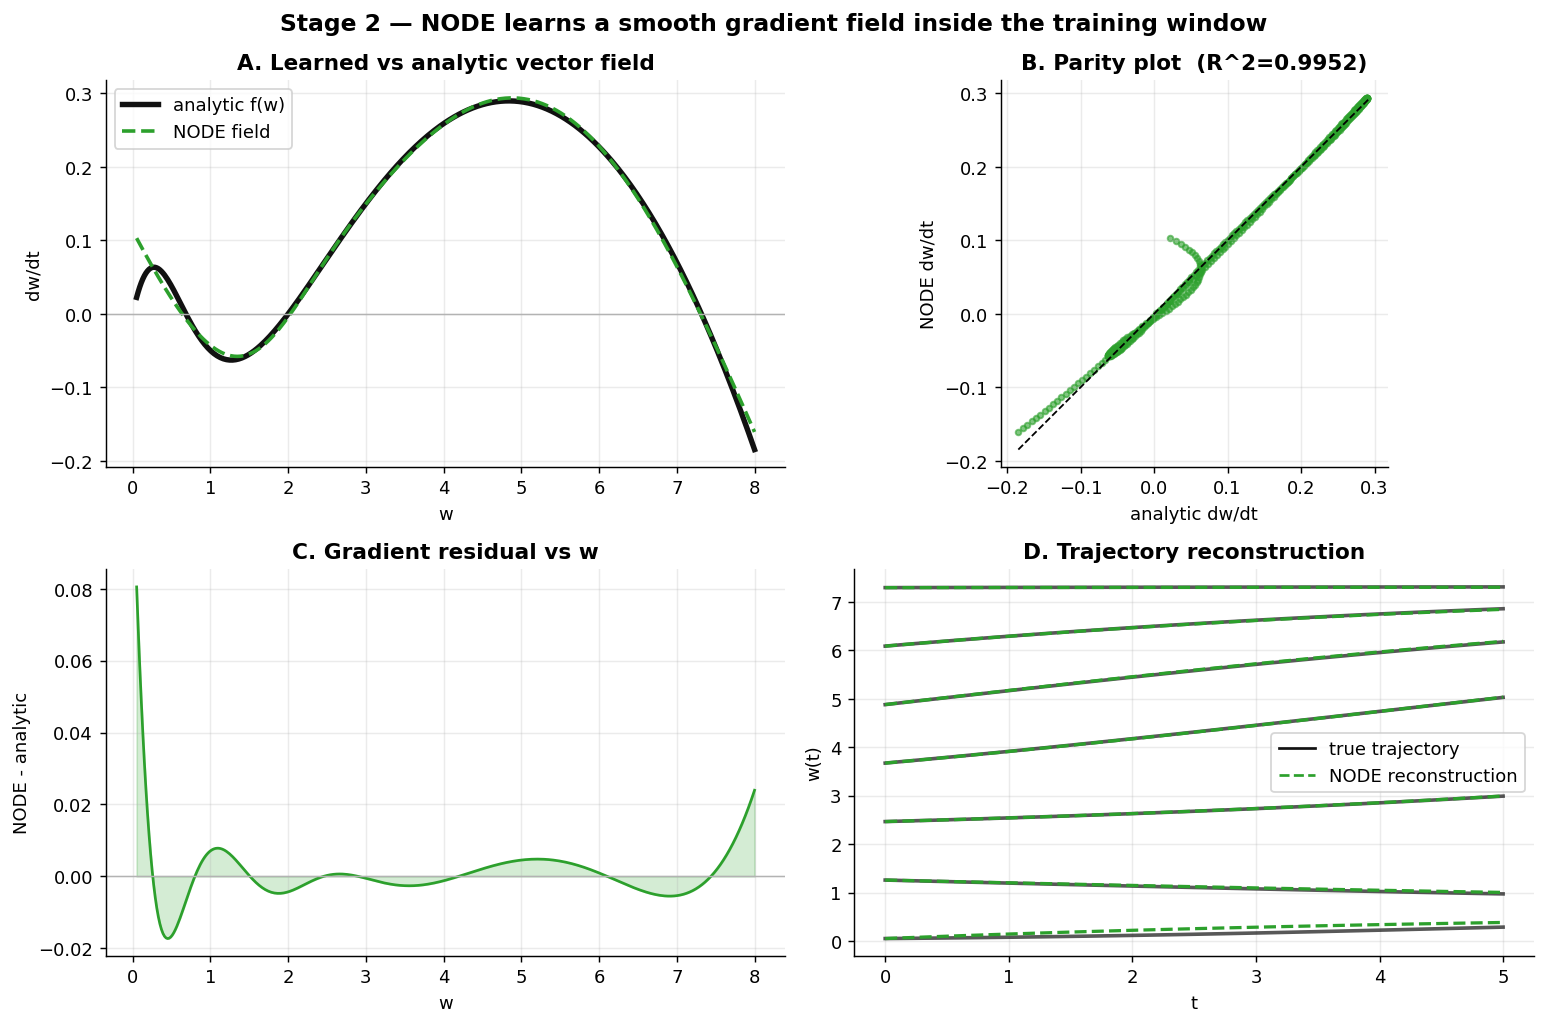

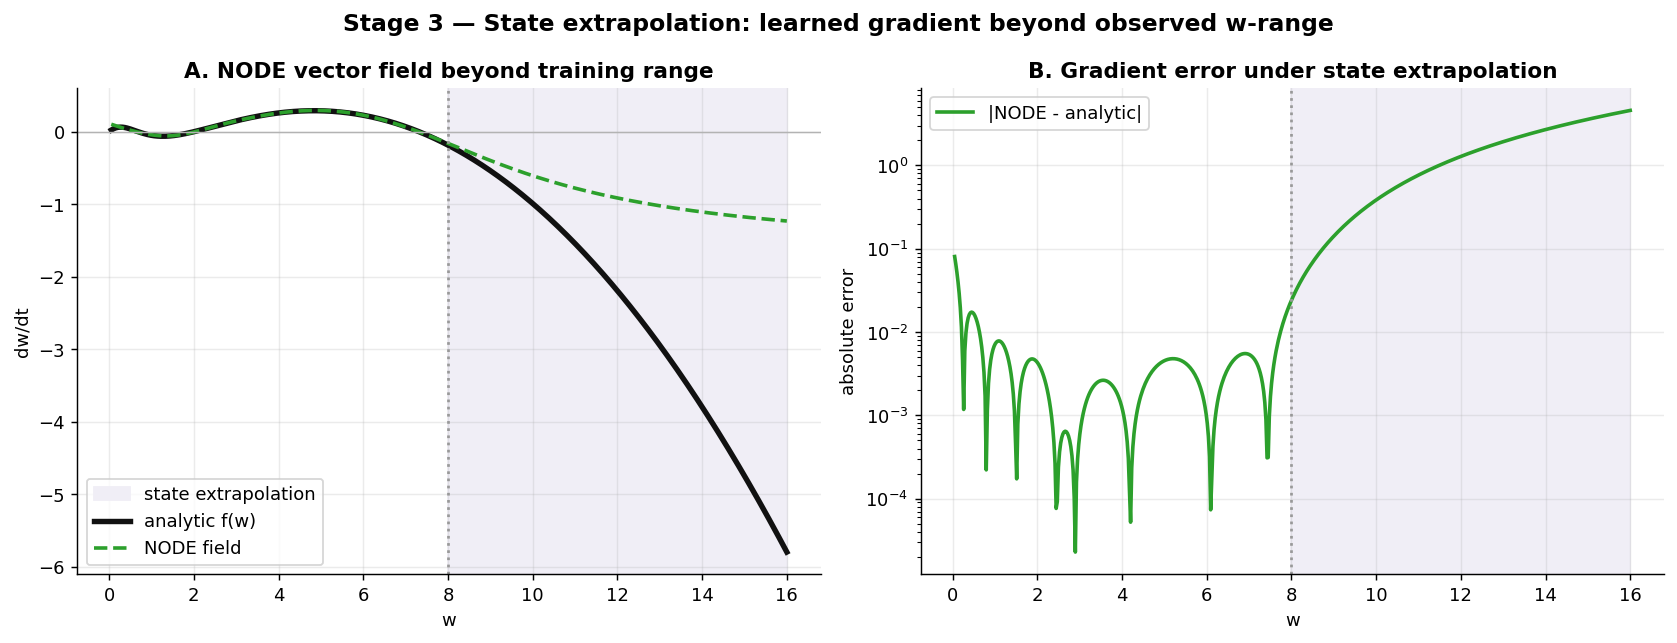

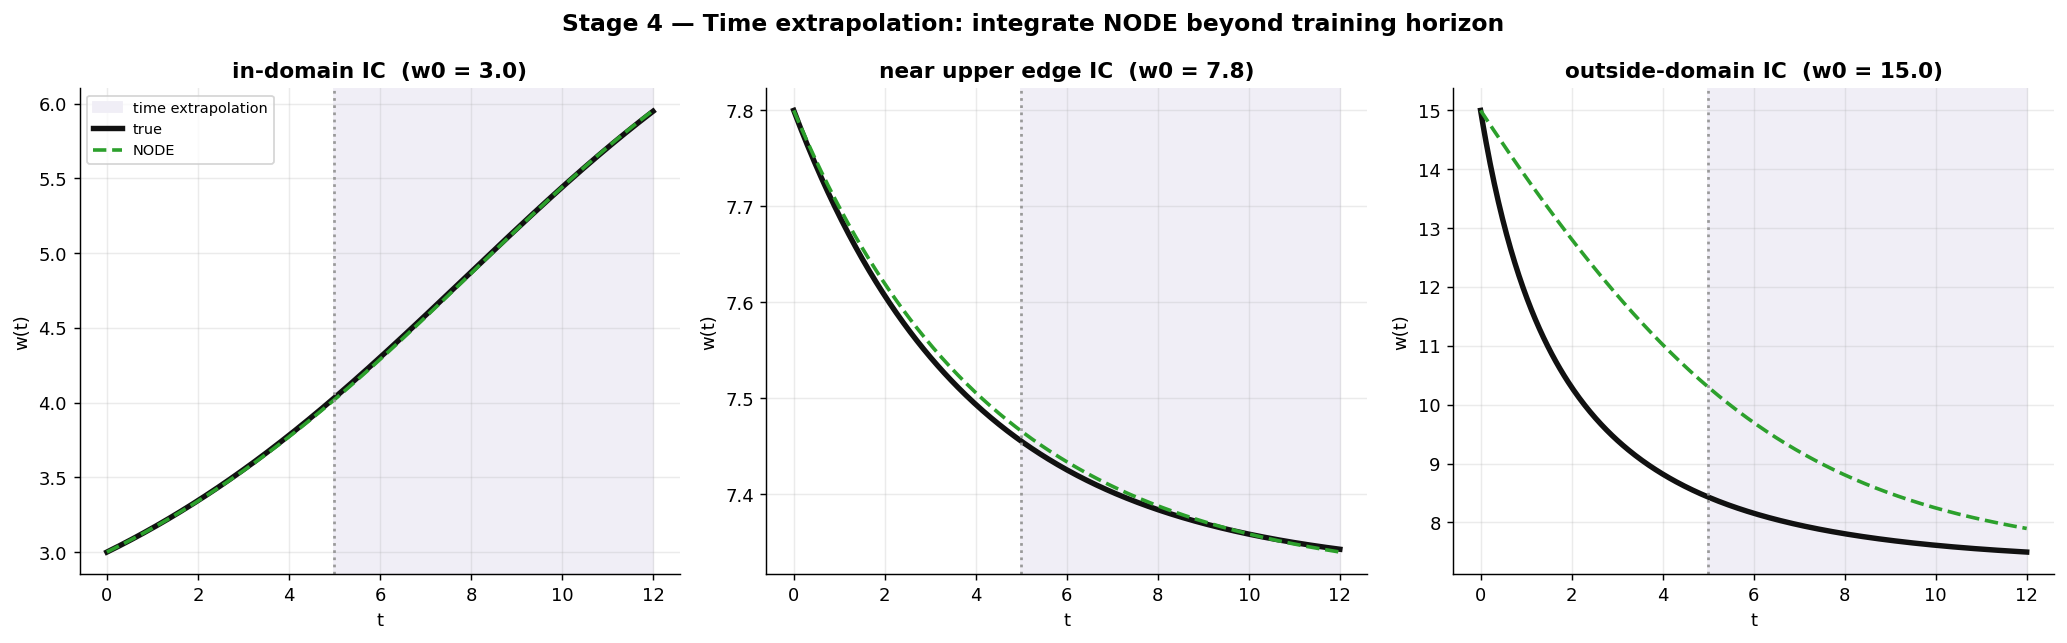

In [2]:

# Figure 1: NODE gradient validation

fig1 = plt.figure(figsize=(12, 8))
gs = GridSpec(2, 2, figure=fig1)

# A. Learned vector field
ax = fig1.add_subplot(gs[0, 0])
ax.plot(wd, f_true, color=C["true"], lw=3, label="analytic f(w)")
ax.plot(wd, f_node, "--", color=C["node"], lw=2, label="NODE field")
ax.axhline(0, color="0.7", lw=0.8)
ax.set(
    xlabel="w",
    ylabel="dw/dt",
    title="A. Learned vs analytic vector field",
)
ax.legend()
ax = fig1.add_subplot(gs[0, 1])
ax.scatter(f_true, f_node, s=10, color=C["node"], alpha=0.6)

lim = [
    min(f_true.min(), f_node.min()),
    max(f_true.max(), f_node.max()),
]

ax.plot(lim, lim, "k--", lw=1)
ax.set(
    xlabel="analytic dw/dt",
    ylabel="NODE dw/dt",
    title=f"B. Parity plot  (R^2={field_r2:.4f})",
)
ax.set_aspect("equal", "box")

ax = fig1.add_subplot(gs[1, 0])
resid = f_node - f_true

ax.plot(wd, resid, color=C["node"])
ax.fill_between(wd, resid, color=C["node"], alpha=0.2)
ax.axhline(0, color="0.7", lw=0.8)
ax.set(
    xlabel="w",
    ylabel="NODE - analytic",
    title="C. Gradient residual vs w",
)

ax = fig1.add_subplot(gs[1, 1])

for i in range(0, N_IC, 12):
    rec = integrate_node(vf, ics[i], t)

    ax.plot(t, clean[i], color=C["true"], lw=2, alpha=0.7)
    ax.plot(t, rec, "--", color=C["node"], lw=1.8)

ax.plot([], [], color=C["true"], label="true trajectory")
ax.plot([], [], "--", color=C["node"], label="NODE reconstruction")
ax.set(
    xlabel="t",
    ylabel="w(t)",
    title="D. Trajectory reconstruction",
)
ax.legend()

fig1.suptitle(
    "Stage 2 — NODE learns a smooth gradient field inside the training window",
    fontsize=13,
    fontweight="bold",
)

fig1.tight_layout()
fig1.savefig("./fig1_node_gradient_validation.png")

print("\nSTAGE 3: state extrapolation of learned gradient")

we = np.linspace(W_MIN, W_EXTRAP, 600)

fe_true = true_f(we)
fe_node = node_field(vf, we)

in_mask = we <= W_MAX
ex_mask = we > W_MAX

print(f"  in-domain field R²       = {r2_score(fe_true[in_mask],fe_node[in_mask]):+.4f}")
print(f"  extrapolated field R²    = {r2_score(fe_true[ex_mask],fe_node[ex_mask]):+.4f}")

fig2, ax = plt.subplots(1, 2, figsize=(13, 5))

# A. Vector field outside training window
ax[0].axvspan(W_MAX, W_EXTRAP, color=C["ex"], label="state extrapolation")
ax[0].plot(we, fe_true, color=C["true"], lw=3, label="analytic f(w)")
ax[0].plot(we, fe_node, "--", color=C["node"], lw=2, label="NODE field")
ax[0].axhline(0, color="0.7", lw=0.8)
ax[0].axvline(W_MAX, color="0.6", ls=":")
ax[0].set(
    xlabel="w",
    ylabel="dw/dt",
    title="A. NODE vector field beyond training range",
)
ax[0].legend()

# B. Absolute gradient error
ax[1].axvspan(W_MAX, W_EXTRAP, color=C["ex"])
ax[1].semilogy(
    we,
    np.abs(fe_node - fe_true) + 1e-8,
    color=C["node"],
    lw=2,
    label="|NODE - analytic|",
)
ax[1].axvline(W_MAX, color="0.6", ls=":")
ax[1].set(
    xlabel="w",
    ylabel="absolute error",
    title="B. Gradient error under state extrapolation",
)
ax[1].legend()

fig2.suptitle(
    "Stage 3 — State extrapolation: learned gradient beyond observed w-range",
    fontsize=13,
    fontweight="bold",
)

fig2.tight_layout()
fig2.savefig("./fig2_state_extrapolation.png")


print("\nSTAGE 4: time extrapolation of NODE trajectories")

tt = np.linspace(0, T_LONG, 400)

scenarios = [
    ("in-domain IC  (w0 = 3.0)", 3.0),
    ("near upper edge IC  (w0 = 7.8)", 7.8),
    ("outside-domain IC  (w0 = 15.0)", 15.0),
]

fig3, ax = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

for k, (title, w0) in enumerate(scenarios):
    tr_true = integrate_true(w0, tt)
    tr_node = integrate_node(vf, w0, tt)

    train_time_mask = tt <= T_FINAL
    extrap_time_mask = tt > T_FINAL

    print(f"  {title}")
    print(
        f"    trajectory R^2 on t <= {T_FINAL:g}: " f"{r2_score(tr_true[train_time_mask],tr_node[train_time_mask]):+.4f} \n"
        f"    trajectory MAE on t <= {T_FINAL:g}: " f"{mean_absolute_error(tr_true[train_time_mask],tr_node[train_time_mask]):+.4f}\n"
        f"    trajectory RMSE on t <= {T_FINAL:g}: " f"{root_mean_squared_error(tr_true[train_time_mask],tr_node[train_time_mask]):+.4f}\n"
    )
    print(
        f"    trajectory R² on t >  {T_FINAL:g}: " f"{r2_score(tr_true[extrap_time_mask],tr_node[extrap_time_mask]):+.4f} \n"
        f"    trajectory MAE on t <= {T_FINAL:g}: " f"{mean_absolute_error(tr_true[extrap_time_mask],tr_node[extrap_time_mask]):+.4f} \n"
        f"    trajectory RMSE on t <= {T_FINAL:g}: " f"{root_mean_squared_error(tr_true[extrap_time_mask],tr_node[extrap_time_mask]):+.4f}"
    )

    ax[k].axvspan(T_FINAL, T_LONG, color=C["ex"], label="time extrapolation")
    ax[k].plot(tt, tr_true, color=C["true"], lw=3, label="true")
    ax[k].plot(tt, tr_node, "--", color=C["node"], lw=2, label="NODE")
    ax[k].axvline(T_FINAL, color="0.6", ls=":")
    ax[k].set(
        xlabel="t",
        ylabel="w(t)",
        title=title,
    )

    if k == 0:
        ax[k].legend(fontsize=8)

fig3.suptitle(
    "Stage 4 — Time extrapolation: integrate NODE beyond training horizon",
    fontsize=13,
    fontweight="bold",
)

fig3.tight_layout()
fig3.savefig("./fig3_time_extrapolation.png")


### Distillation step 1 — fit symbolic models to the NODE gradient field

Every symbolic method is fit to pairs $\bigl(w,\ \widehat{dw/dt}\bigr)$, where the derivative comes from
`node_field` on a uniform grid `wd` over $[0.05,8]$. **We distill the NODE's field, not the raw data** —
this is where the noise-robust NODE gradient earns its keep.

**Standard SINDy** (`PolynomialLibrary(degree=3)`, `STLSQ`):
- Recovers a cubic: `0.038 − 0.114w + 0.071w² − 0.008w³`, R²≈0.94 vs true.
- ⚠️ A polynomial library **cannot represent** the rational term $w^2/(1+w^2)$, so a cubic is the best it can do.
  This is exactly why SINDy extrapolates poorly later, and the motivation for SINDy-PI and SyMANTIC.

**SyMANTIC** (operators `pow(2)`, `/`, `+1`):
- Fit on the DataFrame `{dw, w}` — **the first column is the target** (`dw`), the rest are features.
- Builds a Pareto front (loss vs complexity). The feature space grows fast (15 → 195 → 17 955); the interactive
  "expand further?" prompt is auto-answered `"no"` via `patch(...)`, so it stops at depth 4 and returns the Pareto set.
- These operators *can in principle* assemble the true form ($w^2$, then $+1$, then divide), so SyMANTIC has a genuine shot at the rational structure.


Discovered equation by NODE-SINDy:
(w)' =  0.038 1 + -0.114 w +  0.071 w^2 + -0.008 w^3
--------------------------------------------------
SINDy vs NODE R^2: 0.9403726043470524
SINDy vs NODE RMSE: 0.03187238157809638
SINDy vs true R^2: 0.9471569359969437
SINDy vs true RMSE: 0.03016972672643724
dw    float64
w     float64
dtype: object
****************************** Initial Feature Expansion Completed with feature space size:  3 *********************************************** 

**************************************** Time taken to create the space is::: 0.002714395523071289  Seconds ********************************************

************************************ 2 Feature Expansion Completed with feature space size::: 15  *********************************************************** 

****************************************** Time taken to create the space is::: 0.05688977241516113  Seconds *************************************************** 

************************************ 3 F

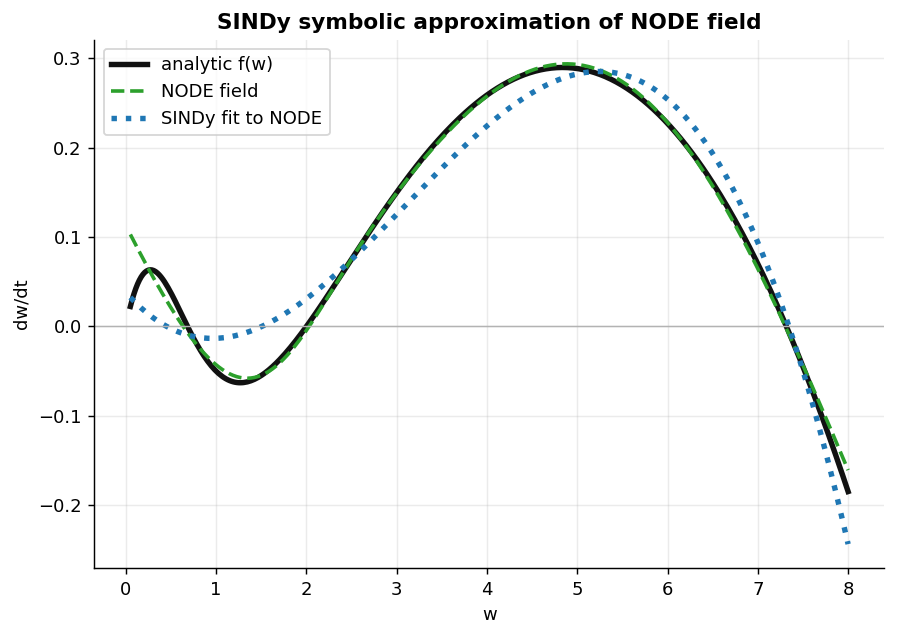

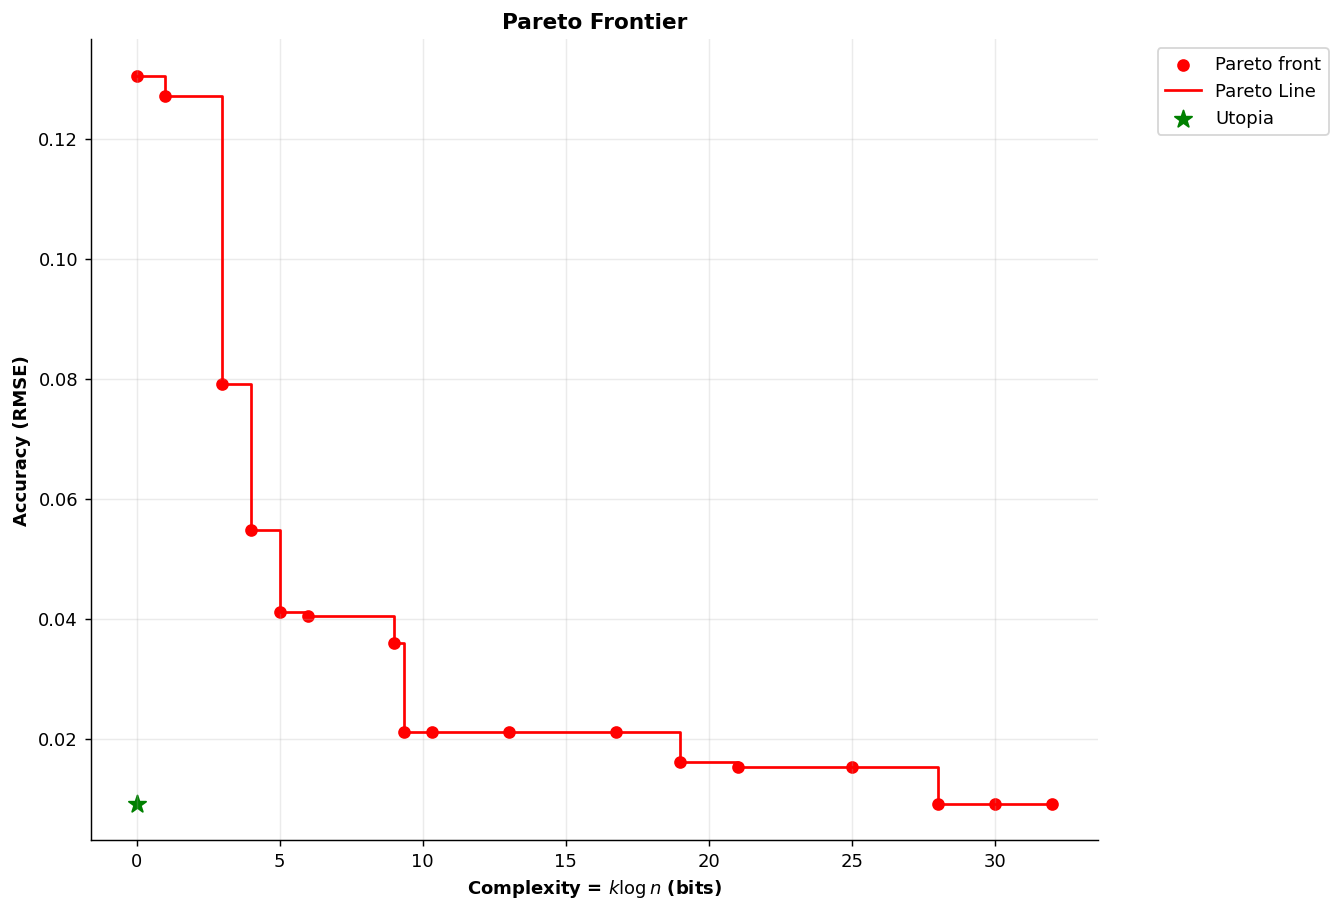

In [12]:
wd_sindy = wd.reshape(-1, 1)
f_node_sindy = f_node.reshape(-1, 1)

import pysindy as ps

standard_model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=3),
    optimizer=ps.STLSQ(threshold=1e-4)
)

standard_model.fit(
    wd_sindy,
    t=1.0,
    x_dot=f_node_sindy,
    feature_names=["w"]
)

print("\nDiscovered equation by NODE-SINDy:")
standard_model.print()
print("-" * 50)
f_sindy = standard_model.predict(wd.reshape(-1, 1)).ravel()

print("SINDy vs NODE R^2:", r2_score(f_node, f_sindy))
print("SINDy vs NODE RMSE:", root_mean_squared_error(f_node, f_sindy))
print("SINDy vs true R^2:", r2_score(f_true, f_sindy))
print("SINDy vs true RMSE:", root_mean_squared_error(f_true, f_sindy))

def sindy_field(model, w):
    w = np.asarray(w, dtype=float).reshape(-1, 1)
    out = model.predict(w)

    return np.asarray(out, dtype=float).reshape(-1)

f_sindy = sindy_field(standard_model, wd)

plt.figure(figsize=(7, 5))
plt.plot(wd, f_true, color=C["true"], lw=3, label="analytic f(w)")
plt.plot(wd, f_node, "--", color=C["node"], lw=2, label="NODE field")
plt.plot(wd, f_sindy, ":", lw=3, label="SINDy fit to NODE")
plt.axhline(0, color="0.7", lw=0.8)
plt.xlabel("w")
plt.ylabel("dw/dt")
plt.title("SINDy symbolic approximation of NODE field")
plt.legend()
plt.tight_layout()
plt.savefig("./fig4_sindy_node_field_fit.png")
f_sindy = sindy_field(standard_model, wd)

from unittest.mock import patch
from model import SymanticModel
import pandas as pd 

import importlib
import model

importlib.invalidate_caches()
importlib.reload(model)

SymanticModel = model.SymanticModel

df_symantic = pd.DataFrame({
    "dw": f_node_sindy.ravel(),
    "w": wd_sindy.ravel(),
}).astype(np.float64)

print(df_symantic.dtypes)

operators = ["pow(2)","/","+1"]
symantic = SymanticModel(
    df_symantic,
    operators=operators,
    metrics=[0.001, 0.99],
    disp=True,
)

with patch("builtins.input", return_value="no"):
    res, pareto = symantic.fit()

symantic.plot_pareto_front()

# Uncomment this when we need to use the n_expansion hardcoded

# symantic = SymanticModel(
#     df_symantic,
#     operators=["pow(2)", "+1","/","*"],
#     n_expansion=4,  # exactly two expansion rounds
#     n_term=3,
#     sis_features=30,
#     metrics=[0.001, 0.99],
#     disp=True,
# )


# rmse, equation, r2 = symantic.fit()

# print("Equation:", equation)
# print("RMSE:", rmse)
# print("R²:", r2)

# symantic.plot_pareto_front()
# df_pareto = symantic.final_df
# df_pareto.Equation.tolist()



### Stage 3B & 4B — does the distilled (polynomial) SINDy model extrapolate?

Push the cubic SINDy field outside the training regime.
- **State (3B):** extrapolated field R² ≈ **−4.6** — the cubic diverges from the true curve for $w>8$
  (a degree-3 polynomial can't flatten out the way the rational truth does). `SINDy vs NODE` extrapolated
  R² ≈ **−380**, i.e. the two disagree wildly out there.
- **Time (4B):** trajectories are passable for in-window ICs but degrade; the outside-domain IC (`w0=15`) goes negative R².

**Takeaway:** polynomial SINDy is a decent in-window *interpolant* of the NODE field but a poor *extrapolator* —
because it is the wrong function class for this rational system.


STAGE 3B: state extrapolation of SINDy model
  NODE  in-domain field R²       = +0.9950
  SINDy in-domain field R²       = +0.9471
  NODE  extrapolated field R²    = -0.6650
  SINDy extrapolated field R²    = -4.6060
  SINDy vs NODE in-domain R²     = +0.9405
  SINDy vs NODE extrapolated R²  = -380.5455

STAGE 4B: time extrapolation of SINDy trajectories
  in-domain IC  (w0 = 3.0)
    SINDy trajectory R² on t <= 5: +0.8602
    SINDy trajectory R² on t >  5: +0.6743
  near upper edge IC  (w0 = 7.8)
    SINDy trajectory R² on t <= 5: +0.9313
    SINDy trajectory R² on t >  5: +0.8940
  outside-domain IC  (w0 = 15.0)
    SINDy trajectory R² on t <= 5: +0.6085
    SINDy trajectory R² on t >  5: -0.4008


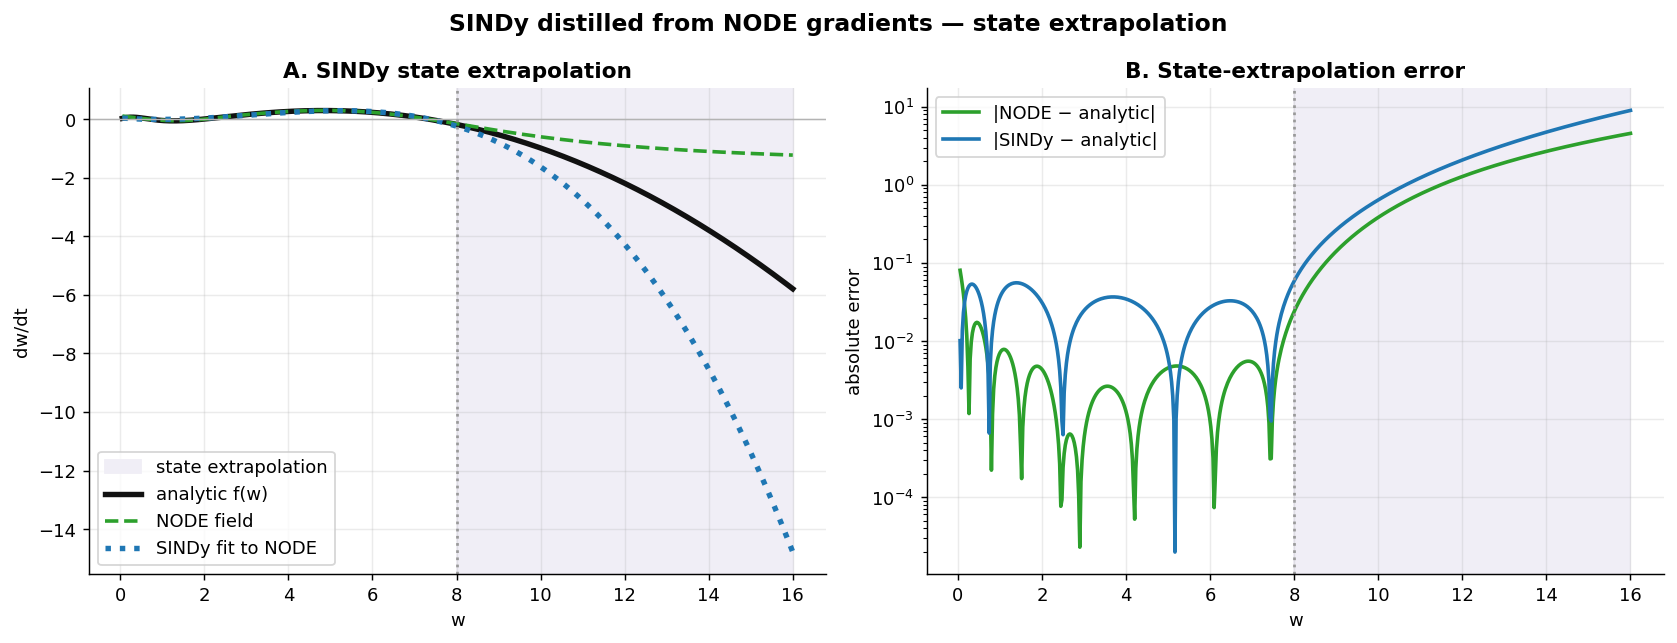

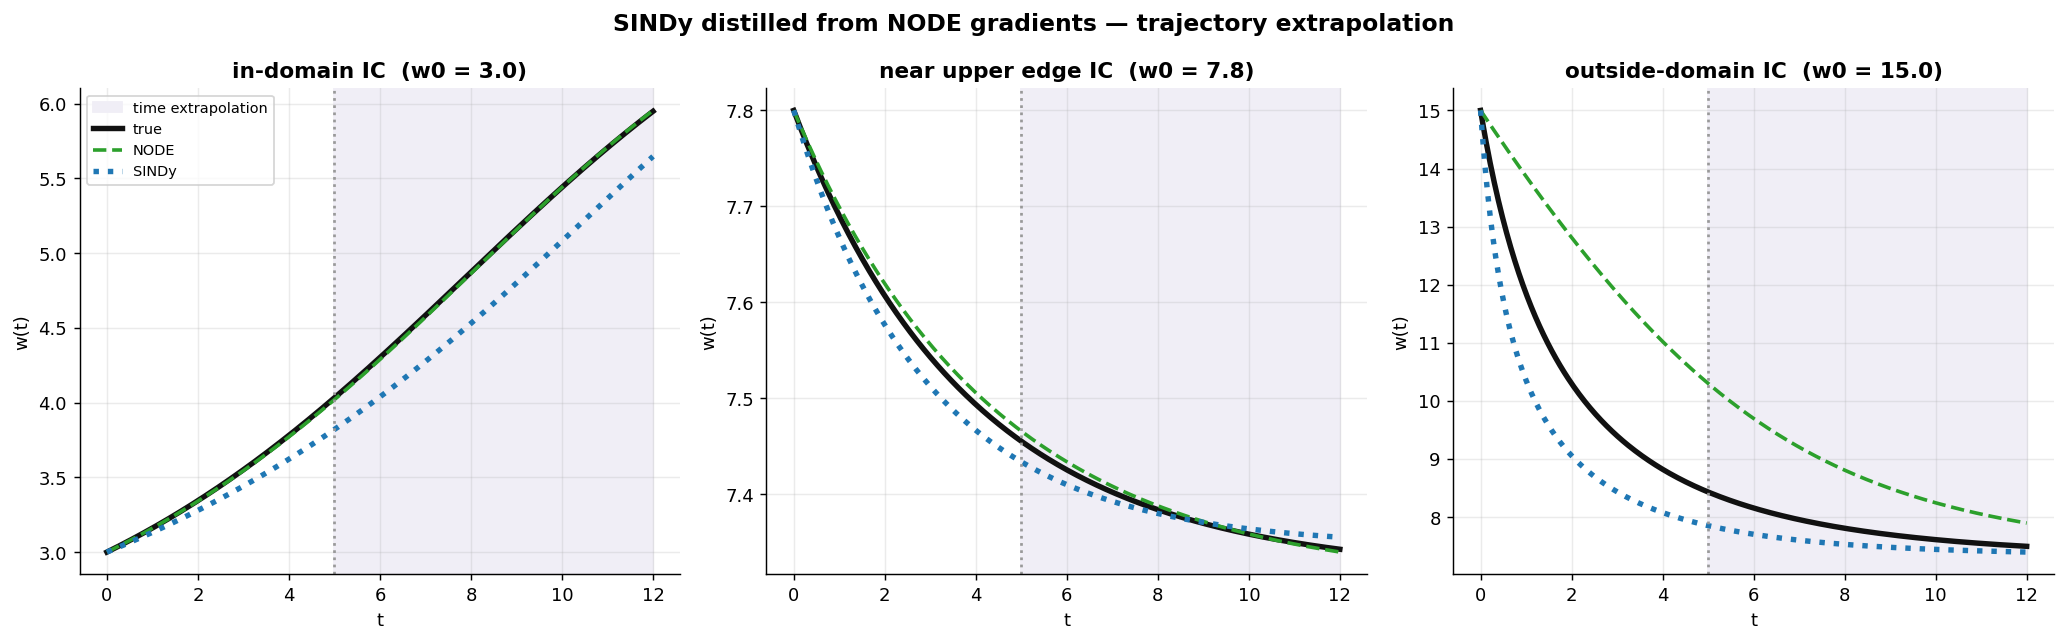

In [13]:
print("\nSTAGE 3B: state extrapolation of SINDy model")

we = np.linspace(W_MIN, W_EXTRAP, 600)

fe_true = true_f(we)
fe_node = node_field(vf, we)
fe_sindy = sindy_field(standard_model, we)

in_mask = we <= W_MAX
ex_mask = we > W_MAX

print(f"  NODE  in-domain field R²       = {r2_score(fe_true[in_mask], fe_node[in_mask]):+.4f}")
print(f"  SINDy in-domain field R²       = {r2_score(fe_true[in_mask], fe_sindy[in_mask]):+.4f}")

print(f"  NODE  extrapolated field R²    = {r2_score(fe_true[ex_mask], fe_node[ex_mask]):+.4f}")
print(f"  SINDy extrapolated field R²    = {r2_score(fe_true[ex_mask], fe_sindy[ex_mask]):+.4f}")

print(f"  SINDy vs NODE in-domain R²     = {r2_score(fe_node[in_mask], fe_sindy[in_mask]):+.4f}")
print(f"  SINDy vs NODE extrapolated R²  = {r2_score(fe_node[ex_mask], fe_sindy[ex_mask]):+.4f}")

fig4, ax = plt.subplots(1, 2, figsize=(13, 5))

# A. Vector fields
ax[0].axvspan(W_MAX, W_EXTRAP, color=C["ex"], label="state extrapolation")
ax[0].plot(we, fe_true, color=C["true"], lw=3, label="analytic f(w)")
ax[0].plot(we, fe_node, "--", color=C["node"], lw=2, label="NODE field")
ax[0].plot(we, fe_sindy, ":", lw=3, label="SINDy fit to NODE")
ax[0].axhline(0, color="0.7", lw=0.8)
ax[0].axvline(W_MAX, color="0.6", ls=":")
ax[0].set(
    xlabel="w",
    ylabel="dw/dt",
    title="A. SINDy state extrapolation",
)
ax[0].legend()

# B. Absolute errors
ax[1].axvspan(W_MAX, W_EXTRAP, color=C["ex"])
ax[1].semilogy(
    we,
    np.abs(fe_node - fe_true) + 1e-8,
    color=C["node"],
    lw=2,
    label="|NODE − analytic|",
)
ax[1].semilogy(
    we,
    np.abs(fe_sindy - fe_true) + 1e-8,
    lw=2,
    label="|SINDy − analytic|",
)
ax[1].axvline(W_MAX, color="0.6", ls=":")
ax[1].set(
    xlabel="w",
    ylabel="absolute error",
    title="B. State-extrapolation error",
)
ax[1].legend()

fig4.suptitle(
    "SINDy distilled from NODE gradients — state extrapolation",
    fontsize=13,
    fontweight="bold",
)

fig4.tight_layout()
fig4.savefig("./fig4_sindy_state_extrapolation.png")

def integrate_sindy(model, w0, t_eval):
    """
    Integrate learned SINDy ODE from initial condition w0.
    """
    def rhs(t, y):
        return [sindy_field(model, [y[0]])[0]]

    sol = solve_ivp(
        rhs,
        (t_eval[0], t_eval[-1]),
        [w0],
        t_eval=t_eval,
        rtol=1e-9,
        atol=1e-11,
        max_step=0.05,
    )

    if sol.y.shape[1] == len(t_eval):
        return sol.y[0]

    out = np.full_like(t_eval, np.nan, dtype=float)
    out[:sol.y.shape[1]] = sol.y[0]
    return out

print("\nSTAGE 4B: time extrapolation of SINDy trajectories")

tt = np.linspace(0, T_LONG, 400)

scenarios = [
    ("in-domain IC  (w0 = 3.0)", 3.0),
    ("near upper edge IC  (w0 = 7.8)", 7.8),
    ("outside-domain IC  (w0 = 15.0)", 15.0),
]

fig5, ax = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for k, (title, w0) in enumerate(scenarios):
    tr_true = integrate_true(w0, tt)
    tr_node = integrate_node(vf, w0, tt)
    tr_sindy = integrate_sindy(standard_model, w0, tt)

    train_time_mask = tt <= T_FINAL
    extrap_time_mask = tt > T_FINAL

    valid_train = train_time_mask & np.isfinite(tr_sindy) & np.isfinite(tr_true)
    valid_extrap = extrap_time_mask & np.isfinite(tr_sindy) & np.isfinite(tr_true)

    print(f"  {title}")

    if valid_train.sum() > 2:
        print(
            f"    SINDy trajectory R² on t <= {T_FINAL:g}: "
            f"{r2_score(tr_true[valid_train], tr_sindy[valid_train]):+.4f}"
        )
    else:
        print(f"    SINDy trajectory R² on t <= {T_FINAL:g}: unavailable")

    if valid_extrap.sum() > 2:
        print(
            f"    SINDy trajectory R² on t >  {T_FINAL:g}: "
            f"{r2_score(tr_true[valid_extrap], tr_sindy[valid_extrap]):+.4f}"
        )
    else:
        print(f"    SINDy trajectory R² on t >  {T_FINAL:g}: unavailable")

    ax[k].axvspan(T_FINAL, T_LONG, color=C["ex"], label="time extrapolation")
    ax[k].plot(tt, tr_true, color=C["true"], lw=3, label="true")
    ax[k].plot(tt, tr_node, "--", color=C["node"], lw=2, label="NODE")
    ax[k].plot(tt, tr_sindy, ":", lw=3, label="SINDy")
    ax[k].axvline(T_FINAL, color="0.6", ls=":")
    ax[k].set(
        xlabel="t",
        ylabel="w(t)",
        title=title,
    )

    if k == 0:
        ax[k].legend(fontsize=8)

fig5.suptitle(
    "SINDy distilled from NODE gradients — trajectory extrapolation",
    fontsize=13,
    fontweight="bold",
)

fig5.tight_layout()
fig5.savefig("./fig5_sindy_time_extrapolation.png")

### Select a SyMANTIC equation, then compare all models (Stages 3C & 4C)

- **Selection.** Takes the **last** Pareto entry (`pareto.Equation.tolist()[-1]`) — the highest-accuracy /
  highest-complexity member — and compiles it into a callable field `symantic_field(w)` via a sandboxed `eval`.
- Selected model: R²≈0.995 vs NODE, complexity 32. It is a rational expression with $(w+1)$-type denominators —
  a **different structure** from the true $1/(1+w^2)$, but a close-fitting surrogate.

**State extrapolation (3C)** — field R² vs analytic derivative:

| model | in-domain | extrapolated |
|---|---|---|
| NODE | +0.995 | −0.67 |
| SINDy | +0.947 | −4.61 |
| **SyMANTIC** | +0.992 | **+0.94** |

SyMANTIC is the only model that stays accurate beyond $w=8$ — a compact rational form generalizes where the NN and the cubic fail.

**Time extrapolation (4C):** SyMANTIC tracks the true trajectory for all three ICs, including the outside-domain `w0=15` case where the NODE collapses.

> ⚠️ **Caveats.** (1) Selecting the *last* Pareto member maximizes complexity for no accuracy gain — a knee/parsimony
> rule is preferable. (2) High R² here means "good-fitting surrogate," **not** "recovered the true physics" — the
> denominator structure differs. (3) `SyMANTIC vs NODE extrapolated ≈ −66` is a *good* sign, not a bug: the NODE field
> is garbage past $w=8$, so matching the **truth** while disagreeing with the **NODE** is exactly what we want.

Selected SyMANTIC model
------------------------
Equation   : -1.8458644017524957*(((w)**2)**2/((w+1))**2) + -2.9654241034208333*((w)**2/(w+1)) + 1.7831993794922985*(w)**2 + 0.11109710438458847
RMSE       : 0.009152813935004516
R²         : 0.9950827071183085
Complexity : 32.0

STAGE 3C: SyMANTIC state extrapolation

Vector-field R² against analytic derivative
------------------------------------------------
NODE     in-domain     : +0.9950
SINDy    in-domain     : +0.9471
SyMANTIC in-domain     : +0.9916

NODE     extrapolated  : -0.6650
SINDy    extrapolated  : -4.6060
SyMANTIC extrapolated  : +0.9434

Agreement with NODE gradients
--------------------------------
SyMANTIC vs NODE in-domain    : +0.9951
SyMANTIC vs NODE extrapolated : -65.6308


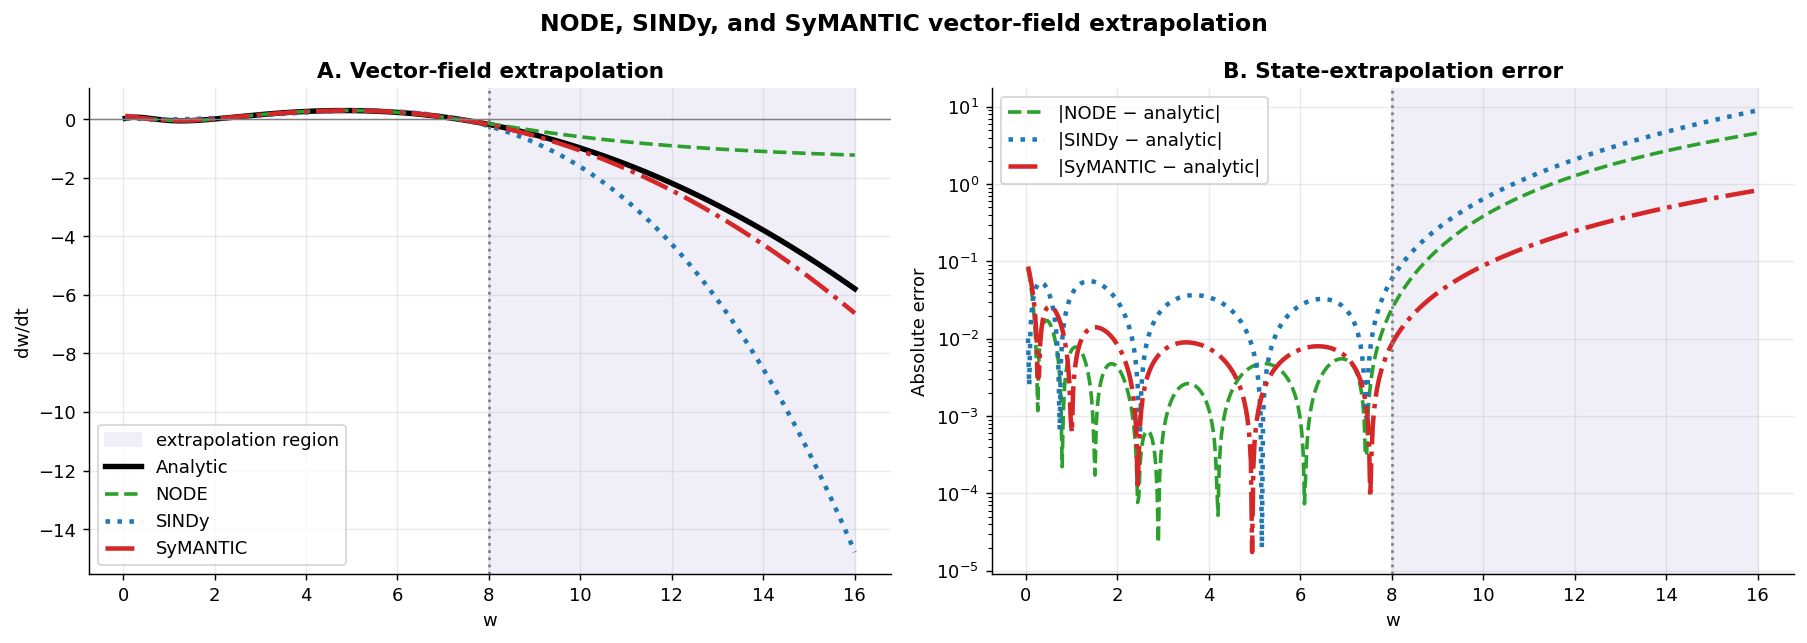


STAGE 4C: SyMANTIC trajectory extrapolation

  in-domain IC (w0 = 3.0)
    NODE     R²(t <= 5) = +0.9995 | R²(t > 5) = +0.9998
    SINDy    R²(t <= 5) = +0.8602 | R²(t > 5) = +0.6743
    SyMANTIC R²(t <= 5) = +0.9902 | R²(t > 5) = +0.9855

  near upper edge IC (w0 = 7.8)
    NODE     R²(t <= 5) = +0.9872 | R²(t > 5) = +0.9736
    SINDy    R²(t <= 5) = +0.9313 | R²(t > 5) = +0.8940
    SyMANTIC R²(t <= 5) = +0.9993 | R²(t > 5) = +0.9805

  outside-domain IC (w0 = 15.0)
    NODE     R²(t <= 5) = -0.5579 | R²(t > 5) = -15.9455
    SINDy    R²(t <= 5) = +0.6085 | R²(t > 5) = -0.4008
    SyMANTIC R²(t <= 5) = +0.9868 | R²(t > 5) = +0.9225


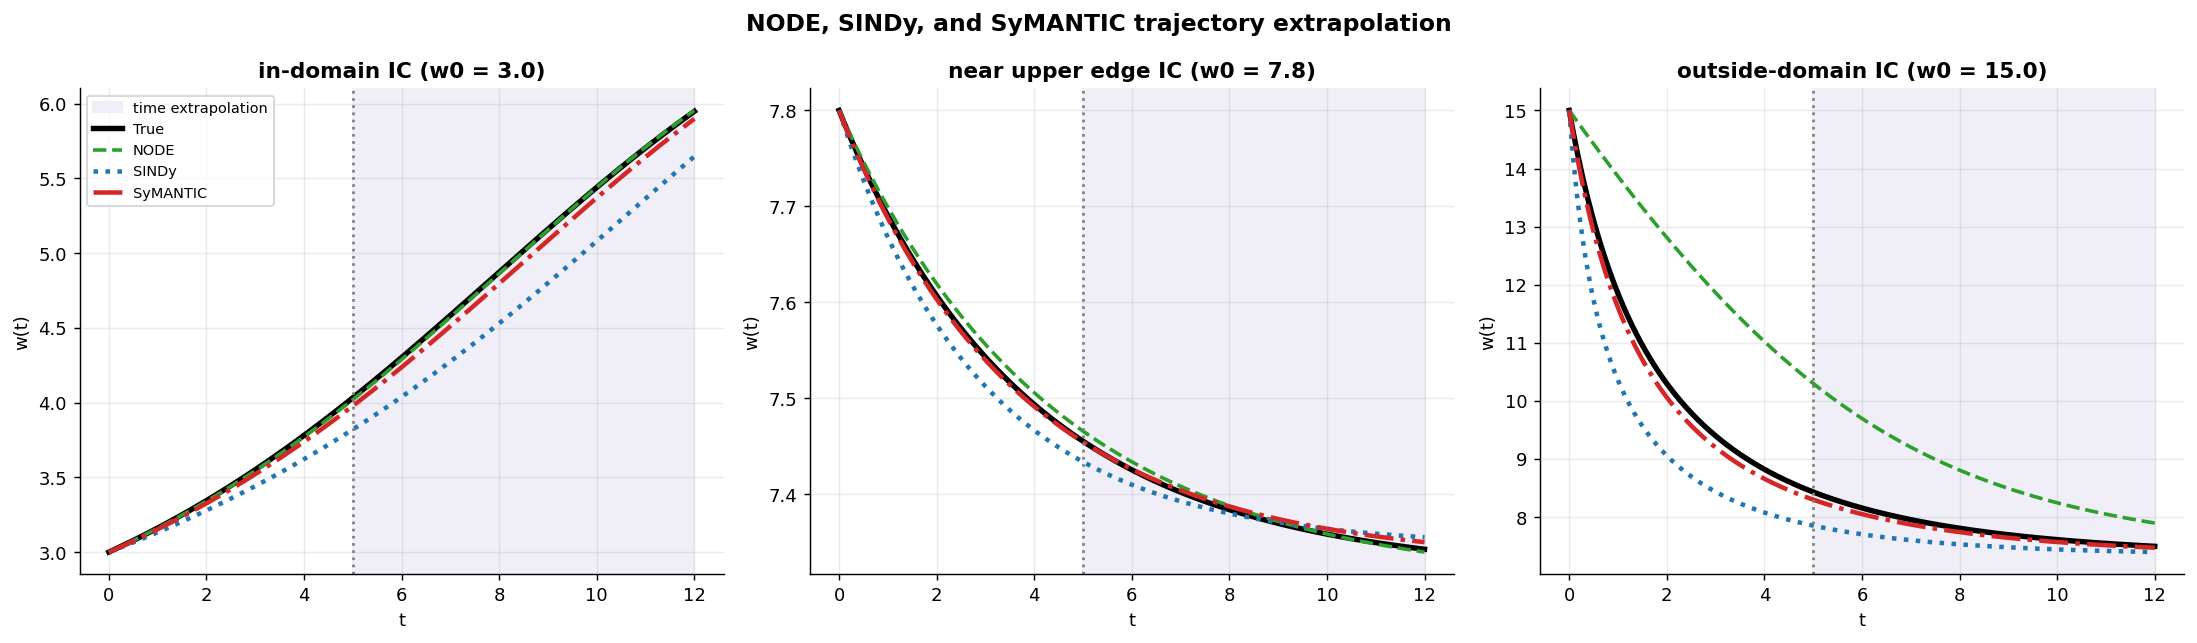

In [14]:


import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from sklearn.metrics import r2_score
from IPython.display import display



symantic_equation = str(pareto.Equation.tolist()[-1])

print("Selected SyMANTIC model")
print("------------------------")
print("Equation   :", symantic_equation)
print("RMSE       :", pareto["Loss"].tolist()[-1])
print("R²         :", pareto["R2"].tolist()[-1])
print("Complexity :", pareto["Complexity"].tolist()[-1])



# ============================================================
# 2. Compile the SyMANTIC equation into a NumPy function
# ============================================================

# Accommodate equations that contain ^ instead of Python's **
symantic_expression = symantic_equation.replace("^", "**")
symantic_code = compile(
    symantic_expression,
    "<symantic_equation>",
    "eval",
)

function_namespace = {
    "exp": np.exp,
    "ln": np.log,
    "log": np.log10,
    "sqrt": np.sqrt,
    "abs": np.abs,
    "sin": np.sin,
    "cos": np.cos,
    "tan": np.tan,
    "sinh": np.sinh,
    "cosh": np.cosh,
    "tanh": np.tanh,
    "asin": np.arcsin,
    "acos": np.arccos,
    "atan": np.arctan,
    "asinh": np.arcsinh,
    "acosh": np.arccosh,
    "atanh": np.arctanh,
    "pow": np.power,
    "np": np,
}


def symantic_field(w):
    """
    Evaluate the selected SyMANTIC vector field dw/dt = f(w).
    """
    original = np.asarray(w, dtype=float)
    values = np.atleast_1d(original).astype(float)

    namespace = dict(function_namespace)
    namespace["w"] = values

    with np.errstate(
        divide="ignore",
        invalid="ignore",
        over="ignore",
        under="ignore",
    ):
        prediction = eval(
            symantic_code,
            {"__builtins__": {}},
            namespace,
        )

    prediction = np.asarray(prediction, dtype=float)

    # Handle constant equations
    if prediction.ndim == 0 or prediction.size == 1:
        prediction = np.full(values.shape, prediction.item())
    else:
        prediction = np.broadcast_to(prediction, values.shape).copy()

    return prediction


def sindy_field_eval(w):
    """
    Evaluate the existing fitted PySINDy model.
    """
    values = np.asarray(w, dtype=float).reshape(-1, 1)
    prediction = standard_model.predict(values)
    return np.asarray(prediction, dtype=float).reshape(-1)


def safe_r2(reference, prediction):
    """
    Calculate R² using only finite values.
    """
    reference = np.asarray(reference, dtype=float)
    prediction = np.asarray(prediction, dtype=float)

    valid = np.isfinite(reference) & np.isfinite(prediction)

    if valid.sum() < 3:
        return np.nan

    return r2_score(reference[valid], prediction[valid])


# ============================================================
# 3. State/vector-field extrapolation
# ============================================================

print("\nSTAGE 3C: SyMANTIC state extrapolation")

we_compare = np.linspace(W_MIN, W_EXTRAP, 600)

field_true = true_f(we_compare)
field_node = node_field(vf, we_compare)
field_sindy = sindy_field_eval(we_compare)
field_symantic = symantic_field(we_compare)

in_domain = we_compare <= W_MAX
extrapolated = we_compare > W_MAX

print("\nVector-field R² against analytic derivative")
print("------------------------------------------------")
print(
    f"NODE     in-domain     : "
    f"{safe_r2(field_true[in_domain], field_node[in_domain]):+.4f}"
)
print(
    f"SINDy    in-domain     : "
    f"{safe_r2(field_true[in_domain], field_sindy[in_domain]):+.4f}"
)
print(
    f"SyMANTIC in-domain     : "
    f"{safe_r2(field_true[in_domain], field_symantic[in_domain]):+.4f}"
)

print()
print(
    f"NODE     extrapolated  : "
    f"{safe_r2(field_true[extrapolated], field_node[extrapolated]):+.4f}"
)
print(
    f"SINDy    extrapolated  : "
    f"{safe_r2(field_true[extrapolated], field_sindy[extrapolated]):+.4f}"
)
print(
    f"SyMANTIC extrapolated  : "
    f"{safe_r2(field_true[extrapolated], field_symantic[extrapolated]):+.4f}"
)

print("\nAgreement with NODE gradients")
print("--------------------------------")
print(
    f"SyMANTIC vs NODE in-domain    : "
    f"{safe_r2(field_node[in_domain], field_symantic[in_domain]):+.4f}"
)
print(
    f"SyMANTIC vs NODE extrapolated : "
    f"{safe_r2(field_node[extrapolated], field_symantic[extrapolated]):+.4f}"
)


# ============================================================
# 4. Plot vector-field extrapolation
# ============================================================

fig_state, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vector fields
axes[0].axvspan(
    W_MAX,
    W_EXTRAP,
    color="#f0eef6",
    label="extrapolation region",
)

axes[0].plot(
    we_compare,
    field_true,
    color="black",
    linewidth=3,
    label="Analytic",
)

axes[0].plot(
    we_compare,
    field_node,
    "--",
    color="#2ca02c",
    linewidth=2,
    label="NODE",
)

axes[0].plot(
    we_compare,
    field_sindy,
    ":",
    color="#1f77b4",
    linewidth=2.5,
    label="SINDy",
)

axes[0].plot(
    we_compare,
    field_symantic,
    "-.",
    color="#d62728",
    linewidth=2.5,
    label="SyMANTIC",
)

axes[0].axvline(W_MAX, color="gray", linestyle=":")
axes[0].axhline(0, color="gray", linewidth=0.8)

axes[0].set(
    xlabel="w",
    ylabel="dw/dt",
    title="A. Vector-field extrapolation",
)

axes[0].legend()


# Absolute errors
axes[1].axvspan(
    W_MAX,
    W_EXTRAP,
    color="#f0eef6",
)

axes[1].semilogy(
    we_compare,
    np.abs(field_node - field_true) + 1e-10,
    "--",
    color="#2ca02c",
    linewidth=2,
    label="|NODE − analytic|",
)

axes[1].semilogy(
    we_compare,
    np.abs(field_sindy - field_true) + 1e-10,
    ":",
    color="#1f77b4",
    linewidth=2.5,
    label="|SINDy − analytic|",
)

axes[1].semilogy(
    we_compare,
    np.abs(field_symantic - field_true) + 1e-10,
    "-.",
    color="#d62728",
    linewidth=2.5,
    label="|SyMANTIC − analytic|",
)

axes[1].axvline(W_MAX, color="gray", linestyle=":")

axes[1].set(
    xlabel="w",
    ylabel="Absolute error",
    title="B. State-extrapolation error",
)

axes[1].legend()

fig_state.suptitle(
    "NODE, SINDy, and SyMANTIC vector-field extrapolation",
    fontsize=13,
    fontweight="bold",
)

fig_state.tight_layout()
fig_state.savefig(
    "./fig_symantic_state_extrapolation.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 5. Generic ODE integration for symbolic models
# ============================================================

def integrate_learned_field(field_function, w0, t_eval, model_name):
    """
    Integrate dw/dt = field_function(w).
    Returns NaN after integration failure.
    """
    t_eval = np.asarray(t_eval, dtype=float)

    def rhs(t, y):
        state = float(y[0])

        # Prevent a divergent symbolic equation from running forever
        if not np.isfinite(state) or abs(state) > 1e6:
            raise FloatingPointError(
                f"{model_name} state diverged: w={state}"
            )

        derivative = field_function(np.array([state]))
        derivative = float(np.asarray(derivative).reshape(-1)[0])

        if not np.isfinite(derivative):
            raise FloatingPointError(
                f"{model_name} returned a non-finite derivative "
                f"at w={state}"
            )

        return [derivative]

    output = np.full(t_eval.shape, np.nan, dtype=float)

    try:
        solution = solve_ivp(
            rhs,
            (t_eval[0], t_eval[-1]),
            [float(w0)],
            t_eval=t_eval,
            rtol=1e-7,
            atol=1e-9,
            max_step=0.05,
        )

        number_returned = solution.y.shape[1]
        output[:number_returned] = solution.y[0]

        if not solution.success:
            print(
                f"    {model_name} integration stopped early: "
                f"{solution.message}"
            )

    except Exception as error:
        print(
            f"    {model_name} integration failed for w0={w0}: "
            f"{error}"
        )

    return output


# ============================================================
# 6. Time/trajectory extrapolation
# ============================================================

print("\nSTAGE 4C: SyMANTIC trajectory extrapolation")

tt_compare = np.linspace(0, T_LONG, 400)

scenarios = [
    ("in-domain IC (w0 = 3.0)", 3.0),
    ("near upper edge IC (w0 = 7.8)", 7.8),
    ("outside-domain IC (w0 = 15.0)", 15.0),
]

fig_time, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5),
    sharey=False,
)

for index, (title, initial_state) in enumerate(scenarios):

    trajectory_true = integrate_true(initial_state, tt_compare)
    trajectory_node = integrate_node(vf, initial_state, tt_compare)

    trajectory_sindy = integrate_learned_field(
        sindy_field_eval,
        initial_state,
        tt_compare,
        "SINDy",
    )

    trajectory_symantic = integrate_learned_field(
        symantic_field,
        initial_state,
        tt_compare,
        "SyMANTIC",
    )

    training_time = tt_compare <= T_FINAL
    extrapolation_time = tt_compare > T_FINAL

    print(f"\n  {title}")

    for model_name, trajectory in [
        ("NODE", trajectory_node),
        ("SINDy", trajectory_sindy),
        ("SyMANTIC", trajectory_symantic),
    ]:
        train_score = safe_r2(
            trajectory_true[training_time],
            trajectory[training_time],
        )

        extrapolation_score = safe_r2(
            trajectory_true[extrapolation_time],
            trajectory[extrapolation_time],
        )

        print(
            f"    {model_name:<8} "
            f"R²(t <= {T_FINAL:g}) = {train_score:+.4f} | "
            f"R²(t > {T_FINAL:g}) = {extrapolation_score:+.4f}"
        )

    axes[index].axvspan(
        T_FINAL,
        T_LONG,
        color="#f0eef6",
        label="time extrapolation",
    )

    axes[index].plot(
        tt_compare,
        trajectory_true,
        color="black",
        linewidth=3,
        label="True",
    )

    axes[index].plot(
        tt_compare,
        trajectory_node,
        "--",
        color="#2ca02c",
        linewidth=2,
        label="NODE",
    )

    axes[index].plot(
        tt_compare,
        trajectory_sindy,
        ":",
        color="#1f77b4",
        linewidth=2.5,
        label="SINDy",
    )

    axes[index].plot(
        tt_compare,
        trajectory_symantic,
        "-.",
        color="#d62728",
        linewidth=2.5,
        label="SyMANTIC",
    )

    axes[index].axvline(
        T_FINAL,
        color="gray",
        linestyle=":",
    )

    axes[index].set(
        xlabel="t",
        ylabel="w(t)",
        title=title,
    )

    if index == 0:
        axes[index].legend(fontsize=8)

fig_time.suptitle(
    "NODE, SINDy, and SyMANTIC trajectory extrapolation",
    fontsize=13,
    fontweight="bold",
)

fig_time.tight_layout()
fig_time.savefig(
    "./fig_symantic_time_extrapolation.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

### SINDy-PI — implicit / rational distillation (Stages 3D & 4D)

Rational dynamics $dw/dt=N(w)/D(w)$ are not a sparse *linear* combination of polynomials, so SINDy-PI clears the
denominator and regresses the **implicit** relation
$$\dot w = \sum_k a_k w^k + \sum_k b_k\,(w^k\dot w)\quad\Rightarrow\quad \dot w = \frac{N(w)}{D(w)},\quad D(w)=1-\sum_k b_k w^k.$$
No `1/(1+w²)` is hand-coded — the denominator is meant to **emerge**. It's solved here with a transparent,
column-normalized STLSQ; the single knob is `PI_THRESHOLD`.

**Result with `PI_THRESHOLD=0.05` (this run):**
- In-domain fit is essentially perfect: **R²=0.9999 vs NODE**, 0.9956 vs true.
- **But** the recovered denominator is a *dense* degree-4 polynomial `(1 − 0.642w + 0.341w² − 0.054w³ + 0.0033w⁴)`,
  **not** the true `(1 + w²)`.
- So it **overfits**: state-extrapolation field R² ≈ **−1.16**, and the `w0=15` trajectory diverges *worse* than the raw NODE.

> **Key lesson (worth a line in any writeup).** SINDy-PI fit the NODE field *better in-domain* than SyMANTIC
> (0.9999 vs 0.995) yet *extrapolated far worse* — a textbook accuracy-vs-parsimony trade-off. To recover the true
> sparse $(1+w^2)$ denominator, **raise `PI_THRESHOLD`** (try 0.1–0.3) so the spurious $w,\,w^3,\,w^4$ denominator
> terms get thresholded out, then compare the printed equation to the `true:` line.

STAGE: SINDy-PI distillation of NODE field

Discovered SINDy-PI model
-------------------------
  dw/dt = (+0.1076 -0.2283*w +0.09464*w**2 -0.002059*w**3 -0.000944*w**4) / (1 -0.642*w +0.3407*w**2 -0.05351*w**3 +0.003267*w**4)
  (true:  dw/dt = (0.5*w -1.05*w**2 +0.5*w**3 -0.05*w**4) / (1 + w**2))

  SINDy-PI vs NODE  R² = +0.9999
  SINDy-PI vs true  R² = +0.9956

STAGE 3D: SINDy-PI state extrapolation
  SINDy-PI in-domain    R² = +0.9955
  SINDy-PI extrapolated R² = -1.1645


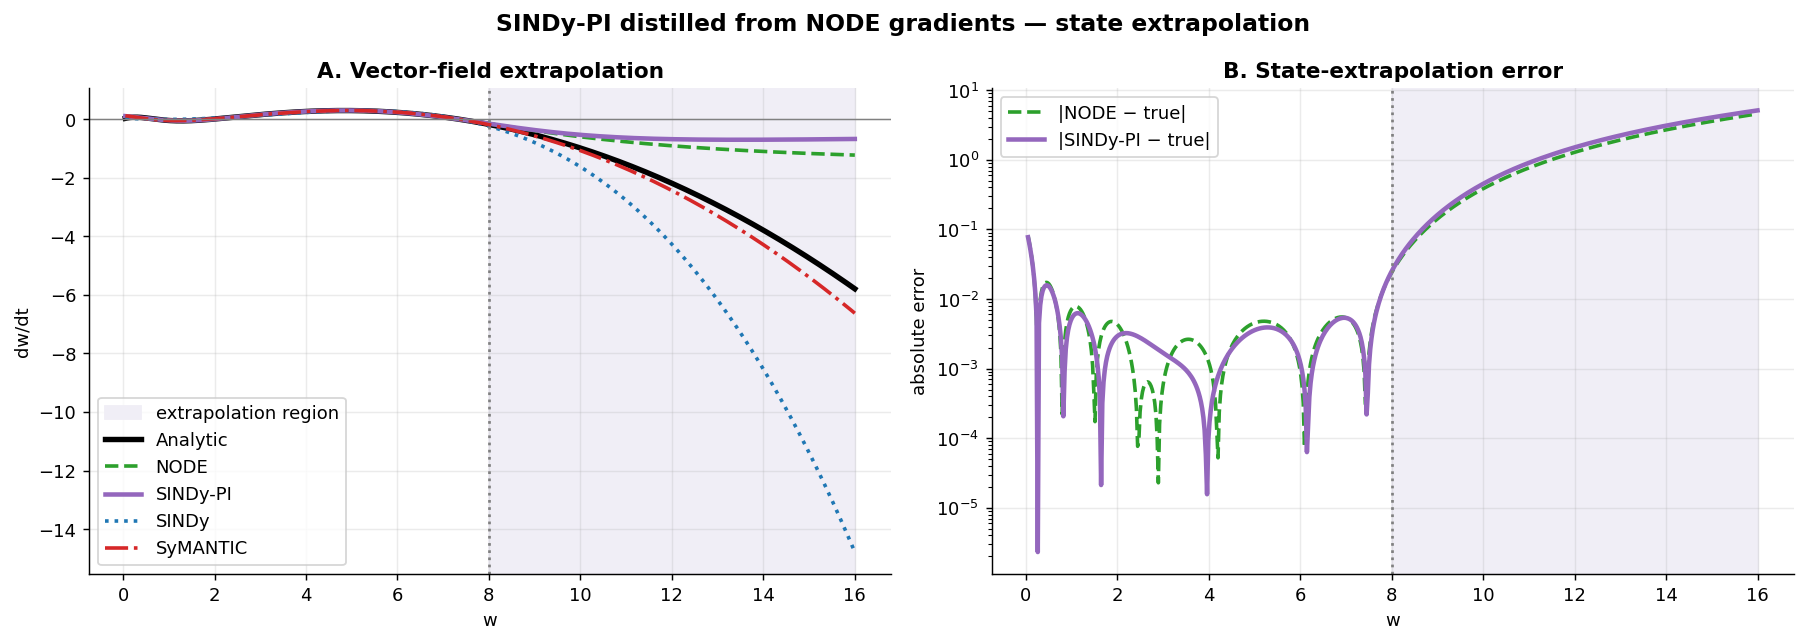


STAGE 4D: SINDy-PI trajectory extrapolation

  in-domain IC (w0 = 3.0)
    NODE     R²(t<= 5)=+0.9995  RMSE(t<= 5)=0.0065 | R²(t> 5)=+0.9998  RMSE(t> 5)=0.0087
    SINDy-PI R²(t<= 5)=+0.9998  RMSE(t<= 5)=0.0044 | R²(t> 5)=+0.9999  RMSE(t> 5)=0.0057

  near upper edge IC (w0 = 7.8)
    NODE     R²(t<= 5)=+0.9872  RMSE(t<= 5)=0.0111 | R²(t> 5)=+0.9736  RMSE(t> 5)=0.0051
    SINDy-PI R²(t<= 5)=+0.9888  RMSE(t<= 5)=0.0104 | R²(t> 5)=+0.9807  RMSE(t> 5)=0.0044

  outside-domain IC (w0 = 15.0)
    NODE     R²(t<= 5)=-0.5579  RMSE(t<= 5)=2.1534 | R²(t> 5)=-15.9455  RMSE(t> 5)=1.0638
    SINDy-PI R²(t<= 5)=-2.0419  RMSE(t<= 5)=3.0090 | R²(t> 5)=-54.7205  RMSE(t> 5)=1.9290


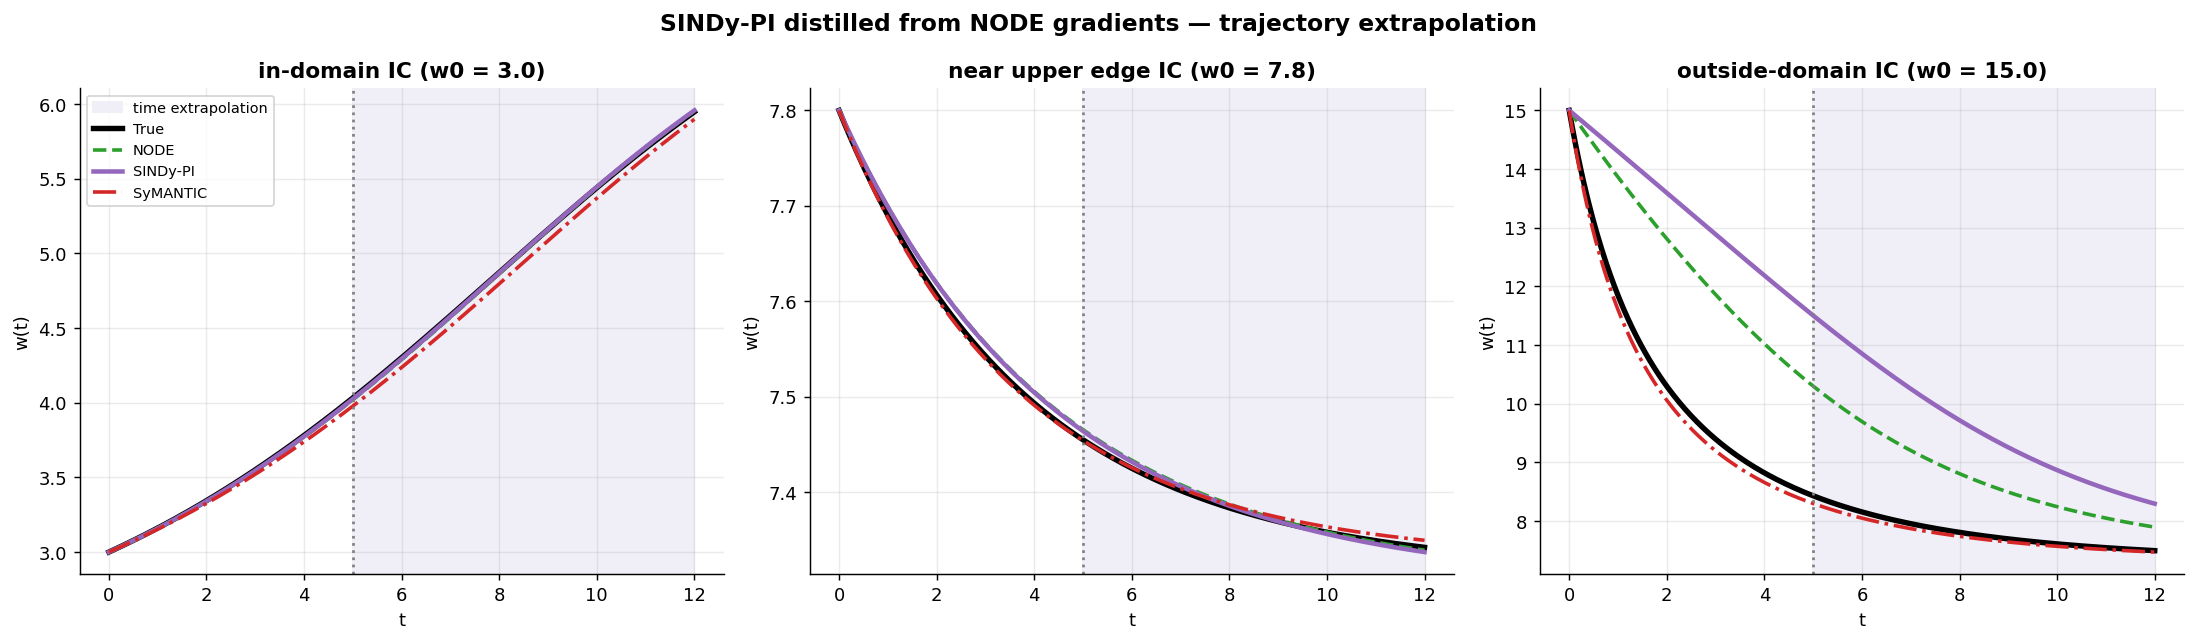

In [15]:
# ============================================================================
# SINDy-PI distillation of the NODE field  (implicit / rational SINDy)
# ----------------------------------------------------------------------------
# Idea: rational dynamics  dw/dt = N(w)/D(w)  cannot be written as a sparse
# linear combo of polynomials, so we go IMPLICIT and clear the denominator:
#
#     dw/dt = sum_k a_k w^k  +  sum_k b_k (w^k * dw/dt)
#  => dw/dt * (1 - sum_k b_k w^k) = sum_k a_k w^k
#  => dw/dt = N(w) / D(w),   N = sum a_k w^k,   D = 1 - sum b_k w^k
#
# We regress dw/dt on the implicit library {w^k} ∪ {w^k * dw/dt} with sparse
# (thresholded) least squares. No 1/(1+w^2) is hand-coded — it emerges.
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.metrics import r2_score

POLY_DEGREE = 4        # must be high enough to clear the denominator (>=4 here)
PI_THRESHOLD = 0.05    # sparsity knob (fraction of signal norm); TUNE THIS
C_PI = "#9467bd"       # purple for SINDy-PI


# ----------------------------------------------------------------------------
# 1. Column-normalized STLSQ (sequential thresholded least squares)
# ----------------------------------------------------------------------------
def _stlsq(Theta, y, threshold, n_iters=50):
    scales = np.linalg.norm(Theta, axis=0)
    scales[scales == 0] = 1.0
    Tn = Theta / scales                       # unit-norm columns -> fair thresholding
    thr = threshold * np.linalg.norm(y)       # threshold relative to signal size

    coef = np.linalg.lstsq(Tn, y, rcond=None)[0]
    for _ in range(n_iters):
        big = np.abs(coef) >= thr
        if not np.any(big):
            break
        new = np.zeros_like(coef)
        new[big] = np.linalg.lstsq(Tn[:, big], y, rcond=None)[0]
        if np.array_equal(np.abs(new) >= thr, big):
            coef = new
            break
        coef = new
    coef[np.abs(coef) < thr] = 0.0
    return coef / scales                       # un-normalize back to real units


# ----------------------------------------------------------------------------
# 2. Fit SINDy-PI to the NODE gradient field
# ----------------------------------------------------------------------------
print("STAGE: SINDy-PI distillation of NODE field")

w_fit = np.linspace(W_MIN, W_MAX, 400)         # distillation grid (same domain as others)
wdot_fit = node_field(vf, w_fit)               # NODE-estimated derivative

num_powers = np.arange(0, POLY_DEGREE + 1)     # 1, w, ..., w^P   (numerator)
den_powers = np.arange(1, POLY_DEGREE + 1)     # w*dw, ..., w^P*dw (implicit/denominator)

num_feats = np.column_stack([w_fit ** k for k in num_powers])
den_feats = np.column_stack([(w_fit ** k) * wdot_fit for k in den_powers])

Theta = np.column_stack([num_feats, den_feats])
coef = _stlsq(Theta, wdot_fit, threshold=PI_THRESHOLD)

a = coef[: len(num_powers)]                    # numerator coeffs   (w^k, k=0..P)
b = coef[len(num_powers):]                     # implicit  coeffs   (w^k*dw, k=1..P)


# ----------------------------------------------------------------------------
# 3. Build the explicit rational field  dw/dt = N(w)/D(w)
# ----------------------------------------------------------------------------
def sindypi_field(w):
    """Evaluate distilled SINDy-PI vector field dw/dt = N(w)/D(w)."""
    w = np.asarray(w, dtype=float)
    N = sum(a[i] * w ** num_powers[i] for i in range(len(num_powers)))
    D = 1.0 - sum(b[j] * w ** den_powers[j] for j in range(len(den_powers)))
    with np.errstate(divide="ignore", invalid="ignore", over="ignore"):
        out = np.divide(N, D, out=np.full(np.shape(w), np.nan, float), where=(D != 0))
    return out


def _poly_str(coeffs, powers, var="w"):
    terms = []
    for c, p in zip(coeffs, powers):
        if abs(c) < 1e-10:
            continue
        if p == 0:
            terms.append(f"{c:+.4g}")
        elif p == 1:
            terms.append(f"{c:+.4g}*{var}")
        else:
            terms.append(f"{c:+.4g}*{var}**{p}")
    return " ".join(terms) if terms else "0"

N_str = _poly_str(a, num_powers)
D_str = "1 " + _poly_str(-b, den_powers)       # D = 1 - sum b_k w^k

print("\nDiscovered SINDy-PI model")
print("-------------------------")
print(f"  dw/dt = ({N_str}) / ({D_str})")
print(f"  (true:  dw/dt = (0.5*w -1.05*w**2 +0.5*w**3 -0.05*w**4) / (1 + w**2))")

f_pi_fit = sindypi_field(w_fit)
print(f"\n  SINDy-PI vs NODE  R² = {r2_score(wdot_fit, f_pi_fit):+.4f}")
print(f"  SINDy-PI vs true  R² = {r2_score(true_f(w_fit), f_pi_fit):+.4f}")


# ----------------------------------------------------------------------------
# 4. Helpers (self-contained so this cell runs standalone)
# ----------------------------------------------------------------------------
def _safe_r2(ref, pred):
    ref, pred = np.asarray(ref, float), np.asarray(pred, float)
    m = np.isfinite(ref) & np.isfinite(pred)
    return r2_score(ref[m], pred[m]) if m.sum() >= 3 else np.nan

def _rmse(ref, pred):
    ref, pred = np.asarray(ref, float), np.asarray(pred, float)
    m = np.isfinite(ref) & np.isfinite(pred)
    return np.sqrt(np.mean((ref[m] - pred[m]) ** 2)) if m.sum() else np.nan

def integrate_field(field_fn, w0, t_eval, name="model"):
    """Integrate dw/dt = field_fn(w); NaN-fill on divergence/failure."""
    t_eval = np.asarray(t_eval, float)
    def rhs(t, y):
        s = float(y[0])
        if not np.isfinite(s) or abs(s) > 1e6:
            raise FloatingPointError(f"{name} state diverged: w={s}")
        d = float(np.asarray(field_fn(np.array([s]))).reshape(-1)[0])
        if not np.isfinite(d):
            raise FloatingPointError(f"{name} non-finite derivative at w={s}")
        return [d]
    out = np.full(t_eval.shape, np.nan, float)
    try:
        sol = solve_ivp(rhs, (t_eval[0], t_eval[-1]), [float(w0)],
                        t_eval=t_eval, rtol=1e-7, atol=1e-9, max_step=0.05)
        out[: sol.y.shape[1]] = sol.y[0]
        if not sol.success:
            print(f"    {name} stopped early: {sol.message}")
    except Exception as e:
        print(f"    {name} integration failed for w0={w0}: {e}")
    return out


# ----------------------------------------------------------------------------
# 5. State / vector-field extrapolation
# ----------------------------------------------------------------------------
print("\nSTAGE 3D: SINDy-PI state extrapolation")

we = np.linspace(W_MIN, W_EXTRAP, 600)
in_mask, ex_mask = we <= W_MAX, we > W_MAX

field_true = true_f(we)
field_node = node_field(vf, we)
field_pi   = sindypi_field(we)

print(f"  SINDy-PI in-domain    R² = {_safe_r2(field_true[in_mask], field_pi[in_mask]):+.4f}")
print(f"  SINDy-PI extrapolated R² = {_safe_r2(field_true[ex_mask], field_pi[ex_mask]):+.4f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].axvspan(W_MAX, W_EXTRAP, color="#f0eef6", label="extrapolation region")
ax[0].plot(we, field_true, color="black", lw=3, label="Analytic")
ax[0].plot(we, field_node, "--", color="#2ca02c", lw=2, label="NODE")
ax[0].plot(we, field_pi, "-", color=C_PI, lw=2.5, label="SINDy-PI")
# overlay standard SINDy / SyMANTIC if those were already fit earlier
if "sindy_field_eval" in globals():
    ax[0].plot(we, sindy_field_eval(we), ":", color="#1f77b4", lw=2, label="SINDy")
if "symantic_field" in globals():
    ax[0].plot(we, symantic_field(we), "-.", color="#d62728", lw=2, label="SyMANTIC")
ax[0].axvline(W_MAX, color="gray", ls=":"); ax[0].axhline(0, color="gray", lw=0.8)
ax[0].set(xlabel="w", ylabel="dw/dt", title="A. Vector-field extrapolation"); ax[0].legend()

ax[1].axvspan(W_MAX, W_EXTRAP, color="#f0eef6")
ax[1].semilogy(we, np.abs(field_node - field_true) + 1e-10, "--", color="#2ca02c", lw=2, label="|NODE − true|")
ax[1].semilogy(we, np.abs(field_pi - field_true) + 1e-10, "-", color=C_PI, lw=2.5, label="|SINDy-PI − true|")
ax[1].axvline(W_MAX, color="gray", ls=":")
ax[1].set(xlabel="w", ylabel="absolute error", title="B. State-extrapolation error"); ax[1].legend()
fig.suptitle("SINDy-PI distilled from NODE gradients — state extrapolation", fontsize=13, fontweight="bold")
fig.tight_layout(); fig.savefig("./fig_sindypi_state_extrapolation.png", dpi=200, bbox_inches="tight")
plt.show()


# ----------------------------------------------------------------------------
# 6. Time / trajectory extrapolation
# ----------------------------------------------------------------------------
print("\nSTAGE 4D: SINDy-PI trajectory extrapolation")

tt = np.linspace(0, T_LONG, 400)
train_mask, ex_time = tt <= T_FINAL, tt > T_FINAL
scenarios = [("in-domain IC (w0 = 3.0)", 3.0),
             ("near upper edge IC (w0 = 7.8)", 7.8),
             ("outside-domain IC (w0 = 15.0)", 15.0)]

fig, ax = plt.subplots(1, 3, figsize=(17, 5), sharey=False)
for k, (title, w0) in enumerate(scenarios):
    tr_true = integrate_true(w0, tt)
    tr_node = integrate_node(vf, w0, tt)
    tr_pi   = integrate_field(sindypi_field, w0, tt, "SINDy-PI")

    print(f"\n  {title}")
    for nm, tr in [("NODE", tr_node), ("SINDy-PI", tr_pi)]:
        print(f"    {nm:<8} "
              f"R²(t<= {T_FINAL:g})={_safe_r2(tr_true[train_mask], tr[train_mask]):+.4f}  "
              f"RMSE(t<= {T_FINAL:g})={_rmse(tr_true[train_mask], tr[train_mask]):.4f} | "
              f"R²(t> {T_FINAL:g})={_safe_r2(tr_true[ex_time], tr[ex_time]):+.4f}  "
              f"RMSE(t> {T_FINAL:g})={_rmse(tr_true[ex_time], tr[ex_time]):.4f}")

    ax[k].axvspan(T_FINAL, T_LONG, color="#f0eef6", label="time extrapolation")
    ax[k].plot(tt, tr_true, color="black", lw=3, label="True")
    ax[k].plot(tt, tr_node, "--", color="#2ca02c", lw=2, label="NODE")
    ax[k].plot(tt, tr_pi, "-", color=C_PI, lw=2.5, label="SINDy-PI")
    if "symantic_field" in globals():
        ax[k].plot(tt, integrate_field(symantic_field, w0, tt, "SyMANTIC"),
                   "-.", color="#d62728", lw=2, label="SyMANTIC")
    ax[k].axvline(T_FINAL, color="gray", ls=":")
    ax[k].set(xlabel="t", ylabel="w(t)", title=title)
    if k == 0:
        ax[k].legend(fontsize=8)

fig.suptitle("SINDy-PI distilled from NODE gradients — trajectory extrapolation", fontsize=13, fontweight="bold")
fig.tight_layout(); fig.savefig("./fig_sindypi_time_extrapolation.png", dpi=200, bbox_inches="tight")
plt.show()

## Alternative SyMANTIC selection — best-scoring model from the full set

The cell below repeats the Stage 3C / 4C comparison, but instead of taking the last Pareto entry it selects the
**highest-`Score`** equation from `symantic.final_df` (`idxmax`). Use this variant when you've fixed
`n_expansion` / `n_term` and want the single best-scoring model rather than the Pareto tail.

> ⚠️ Two things to know: (1) this largely **duplicates the SyMANTIC cell above** with a different selection rule —
> the two can land on algebraically-equivalent equations of the same complexity; (2) the output currently shown
> here is from an **earlier (pre-`NOISE_STD=0.05`) run** — re-run it to refresh the numbers.

Selected SyMANTIC model
------------------------
Equation   : -1.8125077134573362*(((w)**2/(w+1))/(w+1)) + 0.6553775834755058*(w)**2 + -0.7173651594251544*(w/((w+1)/(w)**2)) + 0.10718108565814902
RMSE       : 0.009026929543189188
R²         : 0.9951630833462868
Complexity : 32.0


,Loss,Complexity,Score,Equation
20,0.009027,32.0,0.995163,-1.8125077134573362*(((w)**2/(w+1))/(w+1)) + 0...



STAGE 3C: SyMANTIC state extrapolation

Vector-field R² against analytic derivative
------------------------------------------------
NODE     in-domain     : +0.9955
SINDy    in-domain     : +0.9471
SyMANTIC in-domain     : +0.9917

NODE     extrapolated  : -0.5704
SINDy    extrapolated  : -4.3806
SyMANTIC extrapolated  : +0.9523

Agreement with NODE gradients
--------------------------------
SyMANTIC vs NODE in-domain    : +0.9952
SyMANTIC vs NODE extrapolated : -49.4409


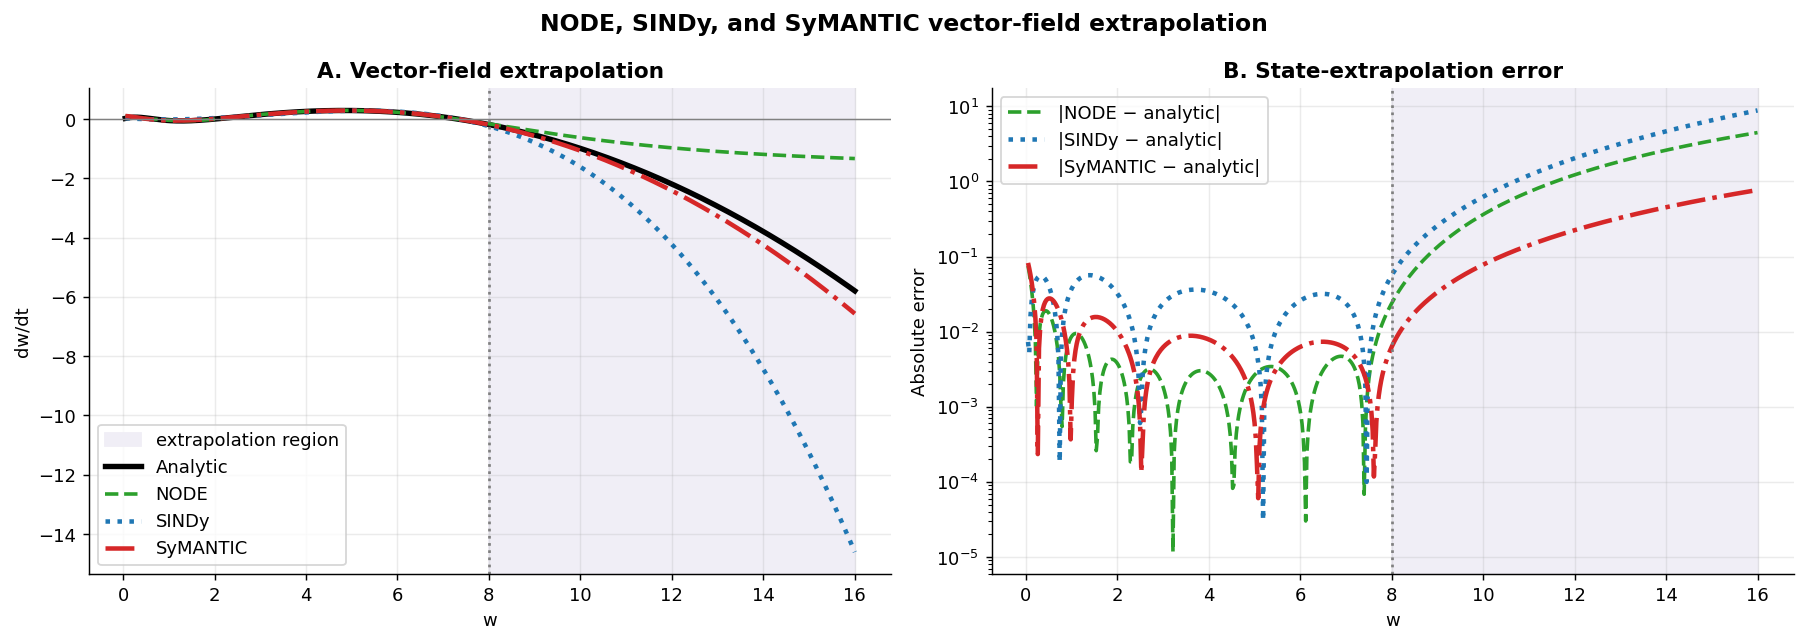


STAGE 4C: SyMANTIC trajectory extrapolation

  in-domain IC (w0 = 3.0)
    NODE     R²(t <= 5) = +0.9999 | R²(t > 5) = +0.9998
    SINDy    R²(t <= 5) = +0.8670 | R²(t > 5) = +0.6838
    SyMANTIC R²(t <= 5) = +0.9912 | R²(t > 5) = +0.9854

  near upper edge IC (w0 = 7.8)
    NODE     R²(t <= 5) = +0.9845 | R²(t > 5) = +0.9503
    SINDy    R²(t <= 5) = +0.9418 | R²(t > 5) = +0.9029
    SyMANTIC R²(t <= 5) = +0.9998 | R²(t > 5) = +0.9484

  outside-domain IC (w0 = 15.0)
    NODE     R²(t <= 5) = -0.3446 | R²(t > 5) = -12.1314
    SINDy    R²(t <= 5) = +0.6203 | R²(t > 5) = -0.3465
    SyMANTIC R²(t <= 5) = +0.9891 | R²(t > 5) = +0.9415


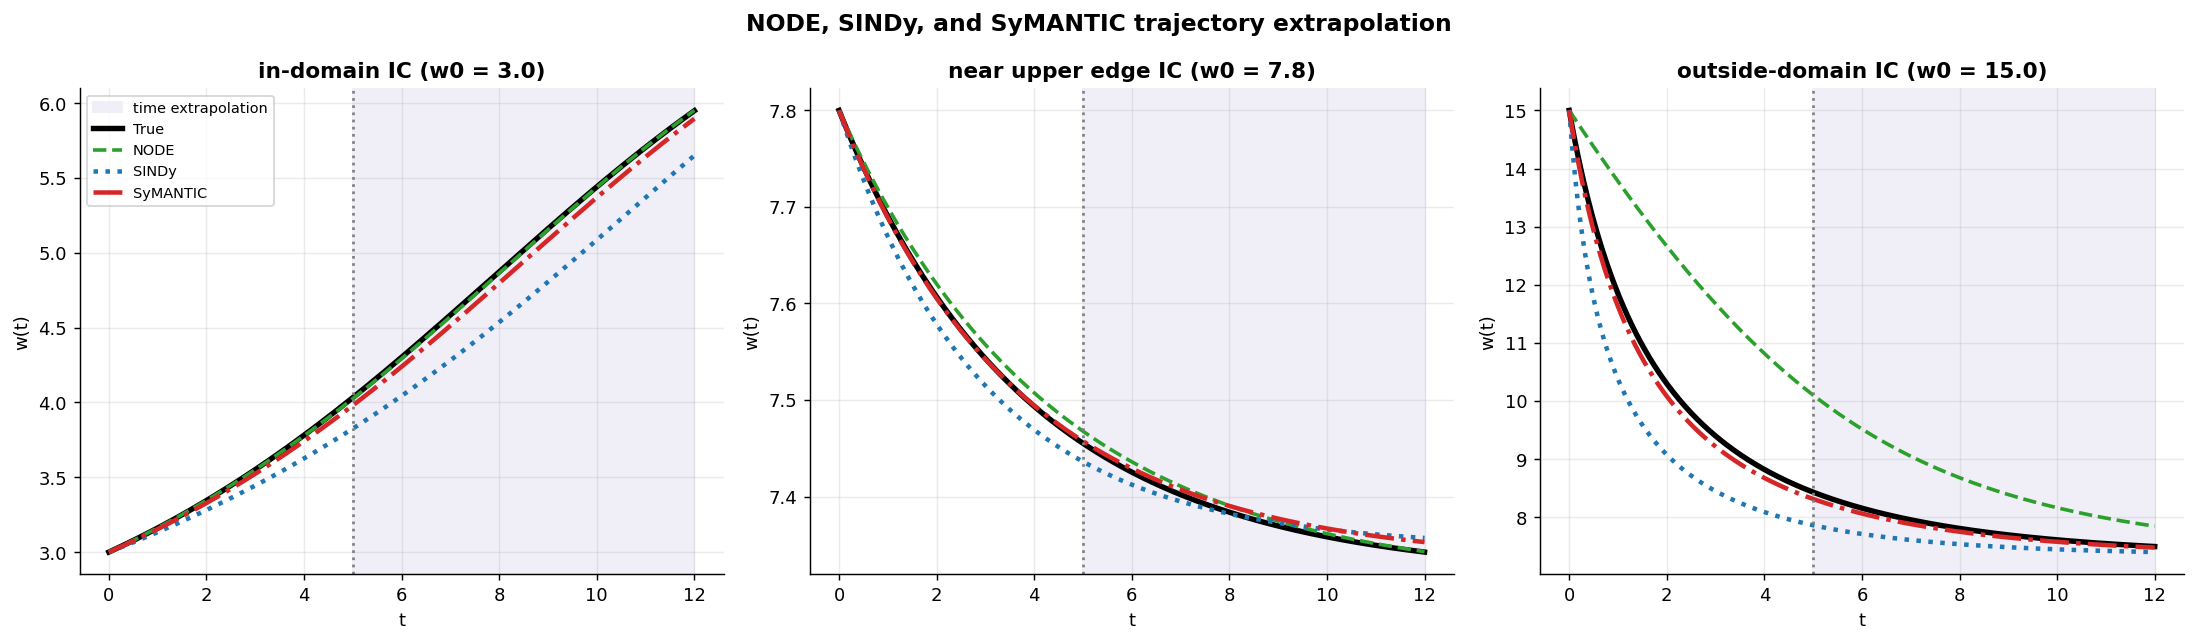

In [5]:


import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from sklearn.metrics import r2_score
from IPython.display import display


# ============================================================
# 1. Select the most accurate equation from SyMANTIC Pareto set
# ============================================================

score_column = "Score" if "Score" in symantic.final_df.columns else "R2"

valid_models = symantic.final_df.dropna(
    subset=["Equation", score_column]
).copy()

best_index = valid_models[score_column].astype(float).idxmax()
best_model = valid_models.loc[best_index]

symantic_equation = str(best_model["Equation"])

print("Selected SyMANTIC model")
print("------------------------")
print("Equation   :", symantic_equation)
print("RMSE       :", best_model["Loss"])
print("R²         :", best_model[score_column])
print("Complexity :", best_model["Complexity"])

display(best_model.to_frame().T)


# ============================================================
# 2. Compile the SyMANTIC equation into a NumPy function
# ============================================================

# Accommodate equations that contain ^ instead of Python's **
symantic_expression = symantic_equation.replace("^", "**")
symantic_code = compile(
    symantic_expression,
    "<symantic_equation>",
    "eval",
)

function_namespace = {
    "exp": np.exp,
    "ln": np.log,
    "log": np.log10,
    "sqrt": np.sqrt,
    "abs": np.abs,
    "sin": np.sin,
    "cos": np.cos,
    "tan": np.tan,
    "sinh": np.sinh,
    "cosh": np.cosh,
    "tanh": np.tanh,
    "asin": np.arcsin,
    "acos": np.arccos,
    "atan": np.arctan,
    "asinh": np.arcsinh,
    "acosh": np.arccosh,
    "atanh": np.arctanh,
    "pow": np.power,
    "np": np,
}


def symantic_field(w):
    """
    Evaluate the selected SyMANTIC vector field dw/dt = f(w).
    """
    original = np.asarray(w, dtype=float)
    values = np.atleast_1d(original).astype(float)

    namespace = dict(function_namespace)
    namespace["w"] = values

    with np.errstate(
        divide="ignore",
        invalid="ignore",
        over="ignore",
        under="ignore",
    ):
        prediction = eval(
            symantic_code,
            {"__builtins__": {}},
            namespace,
        )

    prediction = np.asarray(prediction, dtype=float)

    # Handle constant equations
    if prediction.ndim == 0 or prediction.size == 1:
        prediction = np.full(values.shape, prediction.item())
    else:
        prediction = np.broadcast_to(prediction, values.shape).copy()

    return prediction


def sindy_field_eval(w):
    """
    Evaluate the existing fitted PySINDy model.
    """
    values = np.asarray(w, dtype=float).reshape(-1, 1)
    prediction = standard_model.predict(values)
    return np.asarray(prediction, dtype=float).reshape(-1)


def safe_r2(reference, prediction):
    """
    Calculate R² using only finite values.
    """
    reference = np.asarray(reference, dtype=float)
    prediction = np.asarray(prediction, dtype=float)

    valid = np.isfinite(reference) & np.isfinite(prediction)

    if valid.sum() < 3:
        return np.nan

    return r2_score(reference[valid], prediction[valid])


# ============================================================
# 3. State/vector-field extrapolation
# ============================================================

print("\nSTAGE 3C: SyMANTIC state extrapolation")

we_compare = np.linspace(W_MIN, W_EXTRAP, 600)

field_true = true_f(we_compare)
field_node = node_field(vf, we_compare)
field_sindy = sindy_field_eval(we_compare)
field_symantic = symantic_field(we_compare)

in_domain = we_compare <= W_MAX
extrapolated = we_compare > W_MAX

print("\nVector-field R² against analytic derivative")
print("------------------------------------------------")
print(
    f"NODE     in-domain     : "
    f"{safe_r2(field_true[in_domain], field_node[in_domain]):+.4f}"
)
print(
    f"SINDy    in-domain     : "
    f"{safe_r2(field_true[in_domain], field_sindy[in_domain]):+.4f}"
)
print(
    f"SyMANTIC in-domain     : "
    f"{safe_r2(field_true[in_domain], field_symantic[in_domain]):+.4f}"
)

print()
print(
    f"NODE     extrapolated  : "
    f"{safe_r2(field_true[extrapolated], field_node[extrapolated]):+.4f}"
)
print(
    f"SINDy    extrapolated  : "
    f"{safe_r2(field_true[extrapolated], field_sindy[extrapolated]):+.4f}"
)
print(
    f"SyMANTIC extrapolated  : "
    f"{safe_r2(field_true[extrapolated], field_symantic[extrapolated]):+.4f}"
)

print("\nAgreement with NODE gradients")
print("--------------------------------")
print(
    f"SyMANTIC vs NODE in-domain    : "
    f"{safe_r2(field_node[in_domain], field_symantic[in_domain]):+.4f}"
)
print(
    f"SyMANTIC vs NODE extrapolated : "
    f"{safe_r2(field_node[extrapolated], field_symantic[extrapolated]):+.4f}"
)


# ============================================================
# 4. Plot vector-field extrapolation
# ============================================================

fig_state, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vector fields
axes[0].axvspan(
    W_MAX,
    W_EXTRAP,
    color="#f0eef6",
    label="extrapolation region",
)

axes[0].plot(
    we_compare,
    field_true,
    color="black",
    linewidth=3,
    label="Analytic",
)

axes[0].plot(
    we_compare,
    field_node,
    "--",
    color="#2ca02c",
    linewidth=2,
    label="NODE",
)

axes[0].plot(
    we_compare,
    field_sindy,
    ":",
    color="#1f77b4",
    linewidth=2.5,
    label="SINDy",
)

axes[0].plot(
    we_compare,
    field_symantic,
    "-.",
    color="#d62728",
    linewidth=2.5,
    label="SyMANTIC",
)

axes[0].axvline(W_MAX, color="gray", linestyle=":")
axes[0].axhline(0, color="gray", linewidth=0.8)

axes[0].set(
    xlabel="w",
    ylabel="dw/dt",
    title="A. Vector-field extrapolation",
)

axes[0].legend()


# Absolute errors
axes[1].axvspan(
    W_MAX,
    W_EXTRAP,
    color="#f0eef6",
)

axes[1].semilogy(
    we_compare,
    np.abs(field_node - field_true) + 1e-10,
    "--",
    color="#2ca02c",
    linewidth=2,
    label="|NODE − analytic|",
)

axes[1].semilogy(
    we_compare,
    np.abs(field_sindy - field_true) + 1e-10,
    ":",
    color="#1f77b4",
    linewidth=2.5,
    label="|SINDy − analytic|",
)

axes[1].semilogy(
    we_compare,
    np.abs(field_symantic - field_true) + 1e-10,
    "-.",
    color="#d62728",
    linewidth=2.5,
    label="|SyMANTIC − analytic|",
)

axes[1].axvline(W_MAX, color="gray", linestyle=":")

axes[1].set(
    xlabel="w",
    ylabel="Absolute error",
    title="B. State-extrapolation error",
)

axes[1].legend()

fig_state.suptitle(
    "NODE, SINDy, and SyMANTIC vector-field extrapolation",
    fontsize=13,
    fontweight="bold",
)

fig_state.tight_layout()
fig_state.savefig(
    "./fig_symantic_state_extrapolation.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# 5. Generic ODE integration for symbolic models
# ============================================================

def integrate_learned_field(field_function, w0, t_eval, model_name):
    """
    Integrate dw/dt = field_function(w).
    Returns NaN after integration failure.
    """
    t_eval = np.asarray(t_eval, dtype=float)

    def rhs(t, y):
        state = float(y[0])

        # Prevent a divergent symbolic equation from running forever
        if not np.isfinite(state) or abs(state) > 1e6:
            raise FloatingPointError(
                f"{model_name} state diverged: w={state}"
            )

        derivative = field_function(np.array([state]))
        derivative = float(np.asarray(derivative).reshape(-1)[0])

        if not np.isfinite(derivative):
            raise FloatingPointError(
                f"{model_name} returned a non-finite derivative "
                f"at w={state}"
            )

        return [derivative]

    output = np.full(t_eval.shape, np.nan, dtype=float)

    try:
        solution = solve_ivp(
            rhs,
            (t_eval[0], t_eval[-1]),
            [float(w0)],
            t_eval=t_eval,
            rtol=1e-7,
            atol=1e-9,
            max_step=0.05,
        )

        number_returned = solution.y.shape[1]
        output[:number_returned] = solution.y[0]

        if not solution.success:
            print(
                f"    {model_name} integration stopped early: "
                f"{solution.message}"
            )

    except Exception as error:
        print(
            f"    {model_name} integration failed for w0={w0}: "
            f"{error}"
        )

    return output


# ============================================================
# 6. Time/trajectory extrapolation
# ============================================================

print("\nSTAGE 4C: SyMANTIC trajectory extrapolation")

tt_compare = np.linspace(0, T_LONG, 400)

scenarios = [
    ("in-domain IC (w0 = 3.0)", 3.0),
    ("near upper edge IC (w0 = 7.8)", 7.8),
    ("outside-domain IC (w0 = 15.0)", 15.0),
]

fig_time, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5),
    sharey=False,
)

for index, (title, initial_state) in enumerate(scenarios):

    trajectory_true = integrate_true(initial_state, tt_compare)
    trajectory_node = integrate_node(vf, initial_state, tt_compare)

    trajectory_sindy = integrate_learned_field(
        sindy_field_eval,
        initial_state,
        tt_compare,
        "SINDy",
    )

    trajectory_symantic = integrate_learned_field(
        symantic_field,
        initial_state,
        tt_compare,
        "SyMANTIC",
    )

    training_time = tt_compare <= T_FINAL
    extrapolation_time = tt_compare > T_FINAL

    print(f"\n  {title}")

    for model_name, trajectory in [
        ("NODE", trajectory_node),
        ("SINDy", trajectory_sindy),
        ("SyMANTIC", trajectory_symantic),
    ]:
        train_score = safe_r2(
            trajectory_true[training_time],
            trajectory[training_time],
        )

        extrapolation_score = safe_r2(
            trajectory_true[extrapolation_time],
            trajectory[extrapolation_time],
        )

        print(
            f"    {model_name:<8} "
            f"R²(t <= {T_FINAL:g}) = {train_score:+.4f} | "
            f"R²(t > {T_FINAL:g}) = {extrapolation_score:+.4f}"
        )

    axes[index].axvspan(
        T_FINAL,
        T_LONG,
        color="#f0eef6",
        label="time extrapolation",
    )

    axes[index].plot(
        tt_compare,
        trajectory_true,
        color="black",
        linewidth=3,
        label="True",
    )

    axes[index].plot(
        tt_compare,
        trajectory_node,
        "--",
        color="#2ca02c",
        linewidth=2,
        label="NODE",
    )

    axes[index].plot(
        tt_compare,
        trajectory_sindy,
        ":",
        color="#1f77b4",
        linewidth=2.5,
        label="SINDy",
    )

    axes[index].plot(
        tt_compare,
        trajectory_symantic,
        "-.",
        color="#d62728",
        linewidth=2.5,
        label="SyMANTIC",
    )

    axes[index].axvline(
        T_FINAL,
        color="gray",
        linestyle=":",
    )

    axes[index].set(
        xlabel="t",
        ylabel="w(t)",
        title=title,
    )

    if index == 0:
        axes[index].legend(fontsize=8)

fig_time.suptitle(
    "NODE, SINDy, and SyMANTIC trajectory extrapolation",
    fontsize=13,
    fontweight="bold",
)

fig_time.tight_layout()
fig_time.savefig(
    "./fig_symantic_time_extrapolation.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()